# Random Forest Classifier — Complete Implementation
**With K-Fold Cross-Validation, Neural Network comparison, and Comprehensive Metrics**

Includes:
- K-Fold cross-validation (stratified)
- Confusion matrix
- Accuracy, F1, Recall, Precision, AUC
- ROC curve (TPR vs FPR)
- Per-fold performance tracking
- Neural Network (TF/Keras) training and comparison
- Temperature vs Predicted Label plots with Logistic Regression / IC50
- Violin plots and paper-quality figures


## 0. Imports

In [235]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE          # handles class imbalance
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf

print("="*80)
print("RANDOM FOREST CLASSIFIER - COMPLETE IMPLEMENTATION")
print("="*80)



RANDOM FOREST CLASSIFIER - COMPLETE IMPLEMENTATION


## 0b. Configuration — Dataset Paths & Mode

In [236]:
# ============================================================
# CONFIGURATION
# ============================================================

# Set True to train on TRAIN_CSV and evaluate on a separate TEST_CSV.
# Set False to use only TRAIN_CSV with an internal 75/25 holdout split (original behaviour).
CROSS_DATASET_MODE = False

TRAIN_CSV = r'F:\Experiments\PTT\Spheroids\all data\mcf7\combined_immediate_days.csv'
TEST_CSV  = r'F:\Experiments\PTT\Spheroids\all data\mcf7\combined_incubate_days.csv'

# Exact name of the temperature column in the CSV.
MAX_TEMP_COL = 'Max temp (°C)_day2'

# Set True to apply SelectKBest (mutual info) feature selection (top N_FEATURES).
# Set False to use all engineered features.
USE_FEATURE_SELECTION = False
N_FEATURES = 30

# Choose which day columns to include in feature extraction.
# Any combination of 'day0', 'day1', 'day2' is valid, e.g.:
#   ['day0', 'day1', 'day2']  — all days (default)
#   ['day2']                  — only day2
#   ['day0', 'day2']          — day0 and day2 only
# Set INCLUDE_DELTA = True to also include _delta columns (day-to-day differences).
DAYS_TO_USE   = ['day0', 'day1', 'day2']
INCLUDE_DELTA = False

# How to handle NaN values in features. Options:
#   'median'      — replace NaN with the column median (original behaviour)
#   'interpolate' — interpolate across day0/day1/day2 per spheroid per feature;
#                   any remaining NaNs (e.g. all days missing) fall back to column median
#   'drop'        — drop any row that still contains a NaN after extraction
NAN_STRATEGY = 'interpolate'

# Set True to balance the training set with SMOTE before final model training.
# Set False to train on the original class distribution (imbalanced data).
USE_SMOTE = True

# ── Overfitting control ──────────────────────────────────────────────────────
# Neural Network regularization — applied in sections 8b and 8b-ii
EARLY_STOPPING          = True   # stop training when val_loss plateaus
EARLY_STOPPING_PATIENCE = 5      # epochs without improvement before stopping
DROPOUT_RATE            = 0.3    # dropout after each hidden layer (0.0 = disabled)
L2_REG                  = 0.001  # L2 weight regularization strength (0.0 = disabled)

# ============================================================
print("Configuration:")
print(f"  CROSS_DATASET_MODE      : {CROSS_DATASET_MODE}")
print(f"  TRAIN_CSV               : {TRAIN_CSV}")
if CROSS_DATASET_MODE:
    print(f"  TEST_CSV                : {TEST_CSV}")
else:
    print("  TEST_CSV                : (not used — internal 75/25 split)")
print(f"  MAX_TEMP_COL            : {MAX_TEMP_COL}")
print(f"  USE_FEATURE_SELECTION   : {USE_FEATURE_SELECTION}")
if USE_FEATURE_SELECTION:
    print(f"  N_FEATURES              : {N_FEATURES}")
print(f"  DAYS_TO_USE             : {DAYS_TO_USE}")
print(f"  INCLUDE_DELTA           : {INCLUDE_DELTA}")
print(f"  NAN_STRATEGY            : {NAN_STRATEGY}")
print(f"  USE_SMOTE               : {USE_SMOTE}")
print(f"  EARLY_STOPPING          : {EARLY_STOPPING}  (patience={EARLY_STOPPING_PATIENCE})")
print(f"  DROPOUT_RATE            : {DROPOUT_RATE}")
print(f"  L2_REG                  : {L2_REG}")


Configuration:
  CROSS_DATASET_MODE      : False
  TRAIN_CSV               : F:\Experiments\PTT\Spheroids\all data\mcf7\combined_immediate_days.csv
  TEST_CSV                : (not used — internal 75/25 split)
  MAX_TEMP_COL            : Max temp (°C)_day2
  USE_FEATURE_SELECTION   : False
  DAYS_TO_USE             : ['day0', 'day1', 'day2']
  INCLUDE_DELTA           : False
  NAN_STRATEGY            : interpolate
  USE_SMOTE               : True
  EARLY_STOPPING          : True  (patience=5)
  DROPOUT_RATE            : 0.3
  L2_REG                  : 0.001


## 1. Load and Prepare Data

In [237]:
print("\n[1/7] Loading data...")
OUTPUT_DIR = Path(TRAIN_CSV).parent   # figures and CSVs are saved next to the input file

def _filter_data(df, label=''):
    """Keep only rows with a valid Label_day2 and a valid temperature value."""
    # Must have a day-2 label (target variable)
    df = df[df['Label_day2'].notna()].copy()

    # Must have a temperature measurement — rows without it cannot appear in
    # section 8a plots and add noise, so exclude them up front
    if MAX_TEMP_COL in df.columns:
        before = len(df)
        df = df[df[MAX_TEMP_COL].notna()].copy()
        dropped = before - len(df)
        if label:
            print(f"  {label} dropped (no temperature): {dropped} rows")
    else:
        if label:
            print(f"  WARNING: '{MAX_TEMP_COL}' not found in {label} — temperature filter skipped")

    # Reset to a clean 0-based integer index so loc/iloc are always consistent
    # and duplicate original IDs never cause row multiplication.
    df = df.reset_index(drop=True)
    return df

# Load training data
df_train_raw = pd.read_csv(TRAIN_CSV, sep=',', index_col=0)
df_complete  = _filter_data(df_train_raw, label='Train')

if CROSS_DATASET_MODE:
    # Load a completely separate test file — no rows shared with the training set
    df_test_raw      = pd.read_csv(TEST_CSV, sep=',', index_col=0)
    df_complete_test = _filter_data(df_test_raw, label='Test')
    print(f"  Mode            : CROSS-DATASET")
    print(f"  Train file      : {Path(TRAIN_CSV).name}")
    print(f"  Test  file      : {Path(TEST_CSV).name}")
    print(f"  Train samples   : {len(df_complete)}  "
          f"(Alive={( df_complete['Label_day2']=='Alive').sum()}, Dead={( df_complete['Label_day2']=='Dead').sum()})")
    print(f"  Test  samples   : {len(df_complete_test)}  "
          f"(Alive={(df_complete_test['Label_day2']=='Alive').sum()}, Dead={(df_complete_test['Label_day2']=='Dead').sum()})")
else:
    # Internal split — test set will be carved out in section 7
    df_complete_test = None
    print(f"  Mode         : internal 75/25 split")
    print(f"  Total samples: {len(df_complete)}")
    print(f"  Alive: {(df_complete['Label_day2']=='Alive').sum()}")
    print(f"  Dead:  {(df_complete['Label_day2']=='Dead').sum()}")
    display(df_complete)



[1/7] Loading data...
  Train dropped (no temperature): 0 rows
  Mode         : internal 75/25 split
  Total samples: 302
  Alive: 226
  Dead:  76


,Sheet,merge_number,Name_day0,Index_day0,Wells_day0,multiple_day0,Path 8bcrop_day0,Path segmented_day0,Area (pix2)_day0,Centroid_day0,...,Circularity_day2,Aspect ratio_day2,Mean grey value_day2,Homogeneity_day2,Energy_day2,Correlation_day2,Normalised alb_day2,Max temp (°C)_day2,Label_day2,Area (pix2)_day2
0,Tube 5,1002050.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492324,0.687216,1186.398898,0.972747,0.922287,0.872692,4.972058,62.0,Dead,NaN
1,Tube 5,108050.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.591253,0.699543,429.233646,0.949526,0.882280,0.935659,108.998134,37.0,Alive,NaN
2,Tube 5,1102070.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.528423,0.731262,466.256397,0.975005,0.934149,0.923414,45.771695,54.0,Dead,NaN
3,Tube 5,1202100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.639251,0.927676,1018.305063,0.980441,0.932283,0.898910,4.822731,65.0,Dead,NaN
4,Tube 5,1302130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.681702,0.768969,692.672532,0.970027,0.935418,0.902386,27.321432,62.0,Dead,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,Tube 8,1102060.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.624869,0.631321,264.369466,0.972189,0.896520,0.929960,96.604936,43.0,Alive,2169.0
298,Tube 8,1502180.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.591747,0.594147,197.255132,0.974582,0.910321,0.915853,95.602875,37.0,Alive,1857.5
299,Tube 8,1703240.0,1703240.0,0.0,324.0,False,J:\Culture Cellulaire 3D Microfluidique\PTT\20...,J:\Culture Cellulaire 3D Microfluidique\PTT\20...,1298.5,(75. 72),...,0.649299,0.886664,387.244352,0.970916,0.915027,0.914976,107.752864,37.0,Alive,1767.5
300,Tube 8,1909240.0,1909240.0,0.0,924.0,False,J:\Culture Cellulaire 3D Microfluidique\PTT\20...,J:\Culture Cellulaire 3D Microfluidique\PTT\20...,1175.5,(77. 80),...,0.697895,0.830584,308.627087,0.971705,0.906066,0.932325,102.867817,37.0,Alive,1965.5


## 2. Feature Extraction (No Temperature)

In [238]:
print("\n[2/7] Extracting features...")

# Morphological and texture features to include — temperature columns are deliberately excluded
# to avoid data leakage (temperature is used as a predictor variable later, not a feature)
include_patterns = [
    'Area (pix2)', 'Circularity', 'Solidity', 'Perimeter (pix)', 'Aspect ratio',
    'Mean grey value', 'Energy', 'Homogeneity', 'Correlation', 'Equivalent Diameter (pix)'
]

# Build the day suffixes to retain based on DAYS_TO_USE and INCLUDE_DELTA
_day_suffixes = [f'_{d}' for d in DAYS_TO_USE]
if INCLUDE_DELTA:
    _day_suffixes.append('_delta')   # pre-computed day-to-day difference columns in the CSV


def _apply_nan_strategy(X, strategy):
    """Handle NaN values according to the chosen strategy."""

    if strategy == 'interpolate':
        # For each feature, treat day0/day1/day2 as time steps and interpolate per row.
        # This is biologically meaningful: a missing day1 value is estimated from day0 and day2
        # of the same spheroid rather than from other spheroids.
        day_order = ['_day0', '_day1', '_day2']
        base_groups = {}
        for col in X.columns:
            for suffix in day_order:
                if suffix in col:
                    base = col.replace(suffix, '')
                    base_groups.setdefault(base, {})[suffix] = col
                    break

        X = X.copy()
        for base, suffix_col_map in base_groups.items():
            ordered_cols = [suffix_col_map[s] for s in day_order if s in suffix_col_map]
            if len(ordered_cols) < 2:
                continue   # need at least 2 time points to interpolate
            # axis=1 interpolates across columns (time axis) for each row independently
            interpolated = X[ordered_cols].interpolate(axis=1, limit_direction='both')
            X[ordered_cols] = interpolated

        # Fallback for rows where all days are NaN — use column median
        for col in X.columns:
            if X[col].isna().any():
                X[col] = X[col].fillna(X[col].median())

    elif strategy == 'drop':
        # Remove any row that still has a NaN — simplest approach, loses data
        rows_before = len(X)
        X = X.dropna()
        rows_after = len(X)
        print(f"    'drop' strategy: removed {rows_before - rows_after} rows with NaN "
              f"({rows_before} → {rows_after})")

    else:  # 'median' — replace each NaN with the column median (default)
        X = X.copy()
        for col in X.columns:
            if X[col].isna().any():
                X[col] = X[col].fillna(X[col].median())

    return X


def extract_features(df, label=''):
    """Select numerical morphology columns matching the configured days, then handle NaNs."""
    numerical_features = []
    for col in df.columns:
        if any(pattern in col for pattern in include_patterns):
            if any(suffix in col for suffix in _day_suffixes):
                if df[col].dtype in ['float64', 'int64', 'float32', 'int32']:
                    numerical_features.append(col)

    X = df[numerical_features].copy()
    nan_count = X.isna().sum().sum()
    X = _apply_nan_strategy(X, NAN_STRATEGY)

    if label:
        print(f"  {label} base features : {len(numerical_features)}")
        print(f"  {label} NaN cells     : {nan_count}  →  strategy: '{NAN_STRATEGY}'")
        print(f"  {label} rows after NaN: {len(X)}")
    return X, numerical_features


print(f"  Days used   : {DAYS_TO_USE}  |  delta: {INCLUDE_DELTA}")
X_features, numerical_features = extract_features(df_complete, label='Train')

# When NAN_STRATEGY='drop', rows are removed from X_features.
# Align df_complete to the surviving rows so y and all later index lookups stay consistent.
if len(X_features) < len(df_complete):
    df_complete = df_complete.loc[X_features.index]
    print(f"  df_complete aligned to X_features: {len(df_complete)} rows")

if CROSS_DATASET_MODE:
    X_features_test, _ = extract_features(df_complete_test, label='Test')
    if len(X_features_test) < len(df_complete_test):
        df_complete_test = df_complete_test.loc[X_features_test.index]
        print(f"  df_complete_test aligned to X_features_test: {len(df_complete_test)} rows")
else:
    X_features_test = None



[2/7] Extracting features...
  Days used   : ['day0', 'day1', 'day2']  |  delta: False
  Train base features : 30
  Train NaN cells     : 4874  →  strategy: 'interpolate'
  Train rows after NaN: 302


## 3. Feature Engineering

In [239]:
print("\n[3/7] Engineering features...")

def engineer_features(X_features):
    """
    Create derived features that capture temporal dynamics between days.
    All computations are guarded by existence checks so the function works
    correctly even if only a subset of days was loaded.
    """
    X = X_features.copy()

    # Identify day-specific columns for each relevant feature
    area_day0  = [c for c in X.columns if 'Area' in c and 'day0' in c]
    area_day1  = [c for c in X.columns if 'Area' in c and 'day1' in c]
    area_day2  = [c for c in X.columns if 'Area' in c and 'day2' in c]
    grey_day0  = [c for c in X.columns if 'Mean grey value' in c and 'day0' in c]
    grey_day1  = [c for c in X.columns if 'Mean grey value' in c and 'day1' in c]
    grey_day2  = [c for c in X.columns if 'Mean grey value' in c and 'day2' in c]
    homog_day2 = [c for c in X.columns if 'Homogeneity' in c and 'day2' in c]
    perim_day2 = [c for c in X.columns if 'Perimeter' in c and 'day2' in c]

    # Relative area growth from day0 to day2 (normalised to avoid scale sensitivity)
    if area_day0 and area_day2:
        X['area_growth_0to2'] = (X[area_day2[0]] - X[area_day0[0]]) / (X[area_day0[0]] + 1)
    # Relative area growth from day1 to day2 (captures late-stage dynamics)
    if area_day1 and area_day2:
        X['area_growth_1to2'] = (X[area_day2[0]] - X[area_day1[0]]) / (X[area_day1[0]] + 1)

    # Absolute and relative grey-value change (proxy for internal texture shift)
    if grey_day0 and grey_day2:
        X['grey_change_0to2'] = X[grey_day2[0]] - X[grey_day0[0]]
        X['grey_ratio_0to2']  = X[grey_day2[0]] / (X[grey_day0[0]] + 1)
    if grey_day1 and grey_day2:
        X['grey_change_1to2'] = X[grey_day2[0]] - X[grey_day1[0]]

    # Compactness at day2: 1 for a perfect circle, <1 for irregular shapes
    if area_day2 and perim_day2:
        X['compactness_day2'] = (4 * np.pi * X[area_day2[0]]) / (X[perim_day2[0]]**2 + 1)

    # Combined texture×size feature at day2
    if homog_day2 and area_day2:
        X['homog_area_day2'] = X[homog_day2[0]] * X[area_day2[0]]

    # Interaction term: does grey-value change correlate with area growth?
    if 'grey_change_0to2' in X.columns and 'area_growth_0to2' in X.columns:
        X['grey_area_interaction'] = X['grey_change_0to2'] * X['area_growth_0to2']

    return X

X_features = engineer_features(X_features)
print(f"  Train total features: {X_features.shape[1]}")

if CROSS_DATASET_MODE:
    X_features_test = engineer_features(X_features_test)
    print(f"  Test  total features: {X_features_test.shape[1]}")


[3/7] Engineering features...
  Train total features: 38


## 4. Feature Selection (Top 30)

In [240]:
print("\n[4/7] Feature selection...")

# If NAN_STRATEGY='drop' removed rows, realign df_complete to the surviving rows.
# Use .loc (label-based) not .iloc (position-based) — df_complete may have a
# non-contiguous integer index after filtering, so iloc would match wrong rows.
if len(X_features) < len(df_complete):
    df_complete = df_complete.loc[X_features.index].copy()
    X_features  = X_features.reset_index(drop=True)
    df_complete = df_complete.reset_index(drop=True)

# Binary target: 1 = Alive, 0 = Dead
# Strip whitespace in case of trailing spaces in the CSV label column
y = (df_complete['Label_day2'].str.strip() == 'Alive').astype(int)

print(f"  Samples: {len(y)}  |  Alive: {y.sum()}  |  Dead: {(y==0).sum()}")

# Diagnostic: show label breakdown per temperature — useful to check that
# control samples (e.g. 37 °C) are not accidentally labeled Dead
if MAX_TEMP_COL in df_complete.columns:
    print("\n  Label distribution by temperature:")
    temp_label = df_complete.groupby([MAX_TEMP_COL, df_complete['Label_day2'].str.strip()]).size().unstack(fill_value=0)
    print(temp_label.to_string())
    print()

if USE_FEATURE_SELECTION:
    # SelectKBest with mutual information ranks features by their statistical dependency
    # with the target label — keeps the top N_FEATURES most informative ones
    selector = SelectKBest(mutual_info_classif, k=N_FEATURES)
    X_selected = selector.fit_transform(X_features, y)
    selected_feature_names = X_features.columns[selector.get_support()].tolist()
    print(f"  Selected {X_selected.shape[1]} / {X_features.shape[1]} features (SelectKBest)")
    print(f"  Top 5: {selected_feature_names[:5]}")
else:
    # No selection — pass all engineered features directly to the model
    X_selected = X_features.values
    selected_feature_names = X_features.columns.tolist()
    selector = None
    print(f"  Feature selection disabled — using all {X_selected.shape[1]} features")

if CROSS_DATASET_MODE:
    if len(X_features_test) < len(df_complete_test):
        df_complete_test = df_complete_test.loc[X_features_test.index].copy()
        X_features_test  = X_features_test.reset_index(drop=True)
        df_complete_test = df_complete_test.reset_index(drop=True)
    y_test_ext = (df_complete_test['Label_day2'].str.strip() == 'Alive').astype(int)

    # Align test set to the exact columns chosen during training.
    # Columns missing from the test set are filled with 0 and flagged as warnings.
    train_cols = X_features.columns[selector.get_support()] if USE_FEATURE_SELECTION else X_features.columns
    X_test_aligned = pd.DataFrame(index=df_complete_test.index)
    for col in train_cols:
        if col in X_features_test.columns:
            X_test_aligned[col] = X_features_test[col].values
        else:
            print(f"  WARNING: column '{col}' not found in test set — filling with 0")
            X_test_aligned[col] = 0.0
    X_selected_test = X_test_aligned.values
    print(f"  Test  selected features: {X_selected_test.shape[1]}")
else:
    X_selected_test = None
    y_test_ext      = None



[4/7] Feature selection...
  Samples: 302  |  Alive: 226  |  Dead: 76

  Label distribution by temperature:
Label_day2          Alive  Dead
Max temp (°C)_day2             
37.0                  117     0
40.0                    7     0
41.0                    7     0
42.0                    7     1
43.0                   12     0
44.0                   12     0
45.0                    6     0
46.0                    7     1
47.0                    4     1
48.0                    5     0
49.0                    6     1
50.0                    6     4
51.0                    8     0
52.0                    4     2
53.0                    2     2
54.0                    1     1
55.0                    1     2
56.0                    0     8
57.0                    0     2
58.0                    2     3
59.0                    1     4
60.0                    2     5
61.0                    2     1
62.0                    0     3
63.0                    0     3
64.0                    2  

## 5. K-Fold Cross-Validation (Random Forest)

In [241]:
print("\n[5/7] Running 5-Fold Cross-Validation...")

n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_accuracies,       fold_precisions, fold_recalls  = [], [], []
fold_f1_scores,        fold_auc_scores                = [], []
fold_train_accuracies  = []   # for overfitting analysis

all_y_true, all_y_pred, all_y_proba, all_fold_indices = [], [], [], []
confusion_matrices   = []
fold_val_indices     = []
fold_val_predictions = []

rf_oof_pred  = np.full(len(df_complete), np.nan)
rf_oof_proba = np.full(len(df_complete), np.nan)

print("\n  Fold | Train Acc | Val Acc  | Gap     | Precision | Recall | F1-Score | AUC")
print("  " + "-"*85)

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_selected, y), 1):
    X_train_fold, X_val_fold = X_selected[train_idx], X_selected[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled   = scaler.transform(X_val_fold)

    rf_model = RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf_model.fit(X_train_scaled, y_train_fold)

    # Validation predictions
    y_pred_fold  = rf_model.predict(X_val_scaled)
    y_proba_fold = rf_model.predict_proba(X_val_scaled)[:, 1]

    # Train predictions (for overfitting check)
    y_pred_train_fold = rf_model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train_fold, y_pred_train_fold)

    acc       = accuracy_score(y_val_fold, y_pred_fold)
    prec      = precision_score(y_val_fold, y_pred_fold)
    rec       = recall_score(y_val_fold, y_pred_fold)
    f1        = f1_score(y_val_fold, y_pred_fold)
    auc_score = roc_auc_score(y_val_fold, y_proba_fold)

    fold_train_accuracies.append(train_acc)
    fold_accuracies.append(acc);  fold_precisions.append(prec)
    fold_recalls.append(rec);     fold_f1_scores.append(f1)
    fold_auc_scores.append(auc_score)
    confusion_matrices.append(confusion_matrix(y_val_fold, y_pred_fold))

    all_y_true.extend(y_val_fold);   all_y_pred.extend(y_pred_fold)
    all_y_proba.extend(y_proba_fold); all_fold_indices.extend([fold_idx] * len(y_val_fold))

    fold_val_indices.append(val_idx)
    fold_val_predictions.append(y_pred_fold)

    rf_oof_pred[val_idx]  = y_pred_fold
    rf_oof_proba[val_idx] = y_proba_fold

    gap = train_acc - acc
    print(f"  {fold_idx:4d} | {train_acc:9.4f} | {acc:8.4f} | {gap:+.4f} | {prec:9.4f} | {rec:6.4f} | {f1:8.4f} | {auc_score:7.4f}")


[5/7] Running 5-Fold Cross-Validation...

  Fold | Train Acc | Val Acc  | Gap     | Precision | Recall | F1-Score | AUC
  -------------------------------------------------------------------------------------
     1 |    0.9959 |   0.8361 | +0.1598 |    0.8571 | 0.9333 |   0.8936 |  0.8972
     2 |    0.9876 |   0.8033 | +0.1843 |    0.8696 | 0.8696 |   0.8696 |  0.8638
     3 |    0.9959 |   0.8667 | +0.1292 |    0.9111 | 0.9111 |   0.9111 |  0.8378
     4 |    0.9959 |   0.8667 | +0.1292 |    0.9744 | 0.8444 |   0.9048 |  0.9259
     5 |    0.9959 |   0.8333 | +0.1625 |    0.8431 | 0.9556 |   0.8958 |  0.8830


## 6. Aggregate Cross-Validation Results

In [242]:
print("\n[6/7] Aggregate Cross-Validation Results:")
print("  " + "-"*65)
print(f"  Mean Accuracy:  {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"  Mean Precision: {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"  Mean Recall:    {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"  Mean F1-Score:  {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")
print(f"  Mean AUC:       {np.mean(fold_auc_scores):.4f} ± {np.std(fold_auc_scores):.4f}")

all_y_true  = np.array(all_y_true)
all_y_pred  = np.array(all_y_pred)
all_y_proba = np.array(all_y_proba)

overall_cm = confusion_matrix(all_y_true, all_y_pred)
print(f"\n  Overall Confusion Matrix (all folds combined):")
print(f"              Predicted")
print(f"              Dead  Alive")
print(f"  Actual Dead   {overall_cm[0,0]:3d}    {overall_cm[0,1]:3d}")
print(f"         Alive  {overall_cm[1,0]:3d}    {overall_cm[1,1]:3d}")



[6/7] Aggregate Cross-Validation Results:
  -----------------------------------------------------------------
  Mean Accuracy:  0.8412 ± 0.0238
  Mean Precision: 0.8911 ± 0.0474
  Mean Recall:    0.9028 ± 0.0407
  Mean F1-Score:  0.8950 ± 0.0142
  Mean AUC:       0.8815 ± 0.0298

  Overall Confusion Matrix (all folds combined):
              Predicted
              Dead  Alive
  Actual Dead    50     26
         Alive   22    204


## 6b. Overfitting Analysis


[6b] Overfitting Analysis — Random Forest

  Fold | Train Acc |  Val Acc |     Gap
  ----------------------------------------
     1 |    0.9959 |   0.8361 | +0.1598  ← overfit?
     2 |    0.9876 |   0.8033 | +0.1843  ← overfit?
     3 |    0.9959 |   0.8667 | +0.1292  ← overfit?
     4 |    0.9959 |   0.8667 | +0.1292  ← overfit?
     5 |    0.9959 |   0.8333 | +0.1625  ← overfit?

  Mean train acc : 0.9942
  Mean val acc   : 0.8412
  Mean gap       : +0.1530  (⚠ OVERFITTING DETECTED)


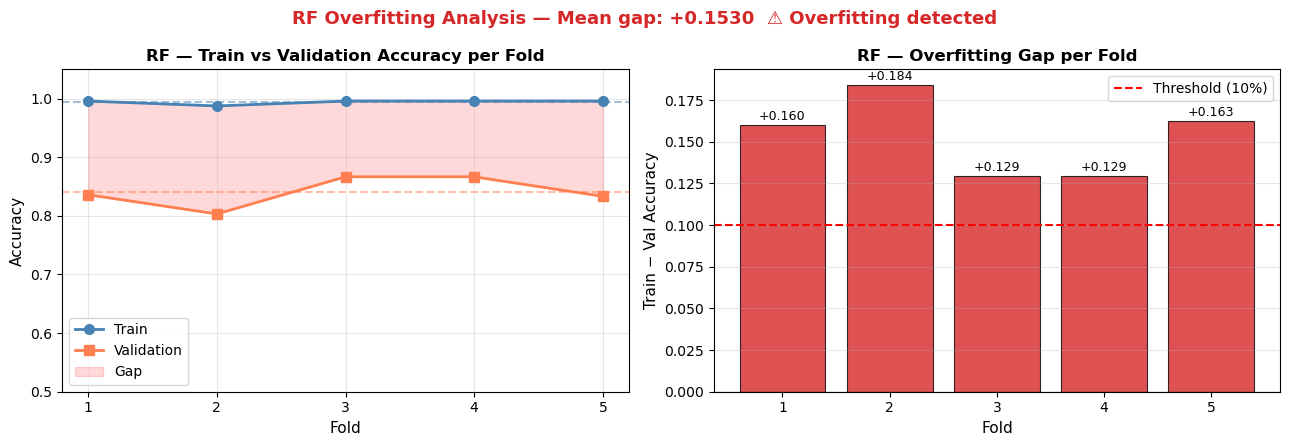

  ✓ Overfitting analysis complete


In [243]:
print("\n[6b] Overfitting Analysis — Random Forest")

OVERFIT_THRESHOLD = 0.10  # gap > 10% is flagged as overfitting

folds       = np.arange(1, n_splits + 1)
gaps        = [tr - val for tr, val in zip(fold_train_accuracies, fold_accuracies)]
mean_gap    = np.mean(gaps)
overfit_flag = mean_gap > OVERFIT_THRESHOLD

print(f"\n  {'Fold':>4} | {'Train Acc':>9} | {'Val Acc':>8} | {'Gap':>7}")
print("  " + "-"*40)
for i, (tr, val, g) in enumerate(zip(fold_train_accuracies, fold_accuracies, gaps), 1):
    flag = "  ← overfit?" if g > OVERFIT_THRESHOLD else ""
    print(f"  {i:4d} | {tr:9.4f} | {val:8.4f} | {g:+.4f}{flag}")
print(f"\n  Mean train acc : {np.mean(fold_train_accuracies):.4f}")
print(f"  Mean val acc   : {np.mean(fold_accuracies):.4f}")
print(f"  Mean gap       : {mean_gap:+.4f}  ({'⚠ OVERFITTING DETECTED' if overfit_flag else '✓ OK'})")

# ── Visualisation ────────────────────────────────────────────────────────────
fig_of, axes_of = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: train vs val accuracy per fold
ax_l = axes_of[0]
ax_l.plot(folds, fold_train_accuracies, 'o-', color='steelblue',  linewidth=2, markersize=7, label='Train')
ax_l.plot(folds, fold_accuracies,       's-', color='coral',      linewidth=2, markersize=7, label='Validation')
ax_l.fill_between(folds, fold_train_accuracies, fold_accuracies,
                  alpha=0.15, color='red', label='Gap')
ax_l.axhline(np.mean(fold_train_accuracies), color='steelblue', linestyle='--', alpha=0.5)
ax_l.axhline(np.mean(fold_accuracies),       color='coral',     linestyle='--', alpha=0.5)
ax_l.set_xlabel('Fold', fontsize=11); ax_l.set_ylabel('Accuracy', fontsize=11)
ax_l.set_title('RF — Train vs Validation Accuracy per Fold', fontsize=12, fontweight='bold')
ax_l.set_xticks(folds); ax_l.set_ylim([0.5, 1.05])
ax_l.legend(); ax_l.grid(True, alpha=0.3)

# Right: gap per fold bar chart
ax_r = axes_of[1]
colors_bar = ['#d62728' if g > OVERFIT_THRESHOLD else '#2ca02c' for g in gaps]
ax_r.bar(folds, gaps, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=0.8)
ax_r.axhline(OVERFIT_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
             label=f'Threshold ({OVERFIT_THRESHOLD:.0%})')
ax_r.axhline(0, color='black', linewidth=0.8)
ax_r.set_xlabel('Fold', fontsize=11); ax_r.set_ylabel('Train − Val Accuracy', fontsize=11)
ax_r.set_title('RF — Overfitting Gap per Fold', fontsize=12, fontweight='bold')
ax_r.set_xticks(folds); ax_r.legend(); ax_r.grid(True, alpha=0.3, axis='y')
for i, g in enumerate(gaps):
    ax_r.text(i + 1, g + 0.003, f'{g:+.3f}', ha='center', fontsize=9)

status_color = '#d62728' if overfit_flag else '#2ca02c'
fig_of.suptitle(
    f'RF Overfitting Analysis — Mean gap: {mean_gap:+.4f}  '
    f'{"⚠ Overfitting detected" if overfit_flag else "✓ No significant overfitting"}',
    fontsize=13, fontweight='bold', color=status_color
)
plt.tight_layout()
plt.show()
print("  ✓ Overfitting analysis complete")

## 7. Train Final Model on All Data (with SMOTE)

In [244]:
print("\n[7/7] Training final model...")

if CROSS_DATASET_MODE:
    # Train on ALL available training data (no holdout) and evaluate on the external test set
    print(f"  Cross-dataset mode: train on {Path(TRAIN_CSV).name}, test on {Path(TEST_CSV).name}")
    X_train_final = X_selected
    y_train_final = y
    X_test_final  = X_selected_test
    y_test_final  = y_test_ext
    _train_pos    = np.arange(len(df_complete))
    _test_pos     = np.arange(len(df_complete_test))
    _df_test      = df_complete_test
else:
    # Internal 75/25 stratified split — stratify=y preserves class ratio in both splits
    _all_indices = np.arange(len(df_complete))
    X_train_final, X_test_final, y_train_final, y_test_final, _train_pos, _test_pos = train_test_split(
        X_selected, y, _all_indices, test_size=0.25, random_state=42, stratify=y
    )
    _df_test = df_complete

# Scale features: fit only on training data to prevent test information leaking into scaling
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled  = scaler_final.transform(X_test_final)   # transform only — no fit

print("Class distribution before balancing:", Counter(y_train_final))
if USE_SMOTE:
    # SMOTE: generate synthetic minority-class samples to balance the training set.
    # Applied after scaling and only on training data — never on the test set.
    smote = SMOTE(sampling_strategy='auto', random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final_scaled, y_train_final)
    print("Class distribution after SMOTE   :", Counter(y_train_balanced))
else:
    # No oversampling — train directly on the original (potentially imbalanced) data
    X_train_balanced, y_train_balanced = X_train_final_scaled, y_train_final
    print("SMOTE disabled — training on original distribution")

# Train the final RF on the (balanced) scaled training set
rf_final = RandomForestClassifier(
    n_estimators=300,       # number of trees — more trees = more stable but slower
    max_depth=10,           # limits tree depth to reduce overfitting
    min_samples_split=5,    # minimum samples required to split a node
    class_weight='balanced',# additional class-weight correction on top of SMOTE
    random_state=42, n_jobs=-1
)
rf_final.fit(X_train_balanced, y_train_balanced)

y_pred_final  = rf_final.predict(X_test_final_scaled)
y_proba_final = rf_final.predict_proba(X_test_final_scaled)[:, 1]   # probability of Alive

final_acc  = accuracy_score(y_test_final, y_pred_final)
final_prec = precision_score(y_test_final, y_pred_final)
final_rec  = recall_score(y_test_final, y_pred_final)
final_f1   = f1_score(y_test_final, y_pred_final)
final_auc  = roc_auc_score(y_test_final, y_proba_final)

test_label = f"External test set ({Path(TEST_CSV).name})" if CROSS_DATASET_MODE else "Test Set (25% holdout)"
print(f"\n  {test_label}:")
print(f"  Accuracy:  {final_acc:.4f}")
print(f"  Precision: {final_prec:.4f}")
print(f"  Recall:    {final_rec:.4f}")
print(f"  F1-Score:  {final_f1:.4f}")
print(f"  AUC:       {final_auc:.4f}")


[7/7] Training final model...
Class distribution before balancing: Counter({1: 169, 0: 57})
Class distribution after SMOTE   : Counter({1: 169, 0: 169})

  Test Set (25% holdout):
  Accuracy:  0.8026
  Precision: 0.9375
  Recall:    0.7895
  F1-Score:  0.8571
  AUC:       0.8504


## 8. Random Forest — Comprehensive Visualizations


[8/8] Creating RF visualizations...


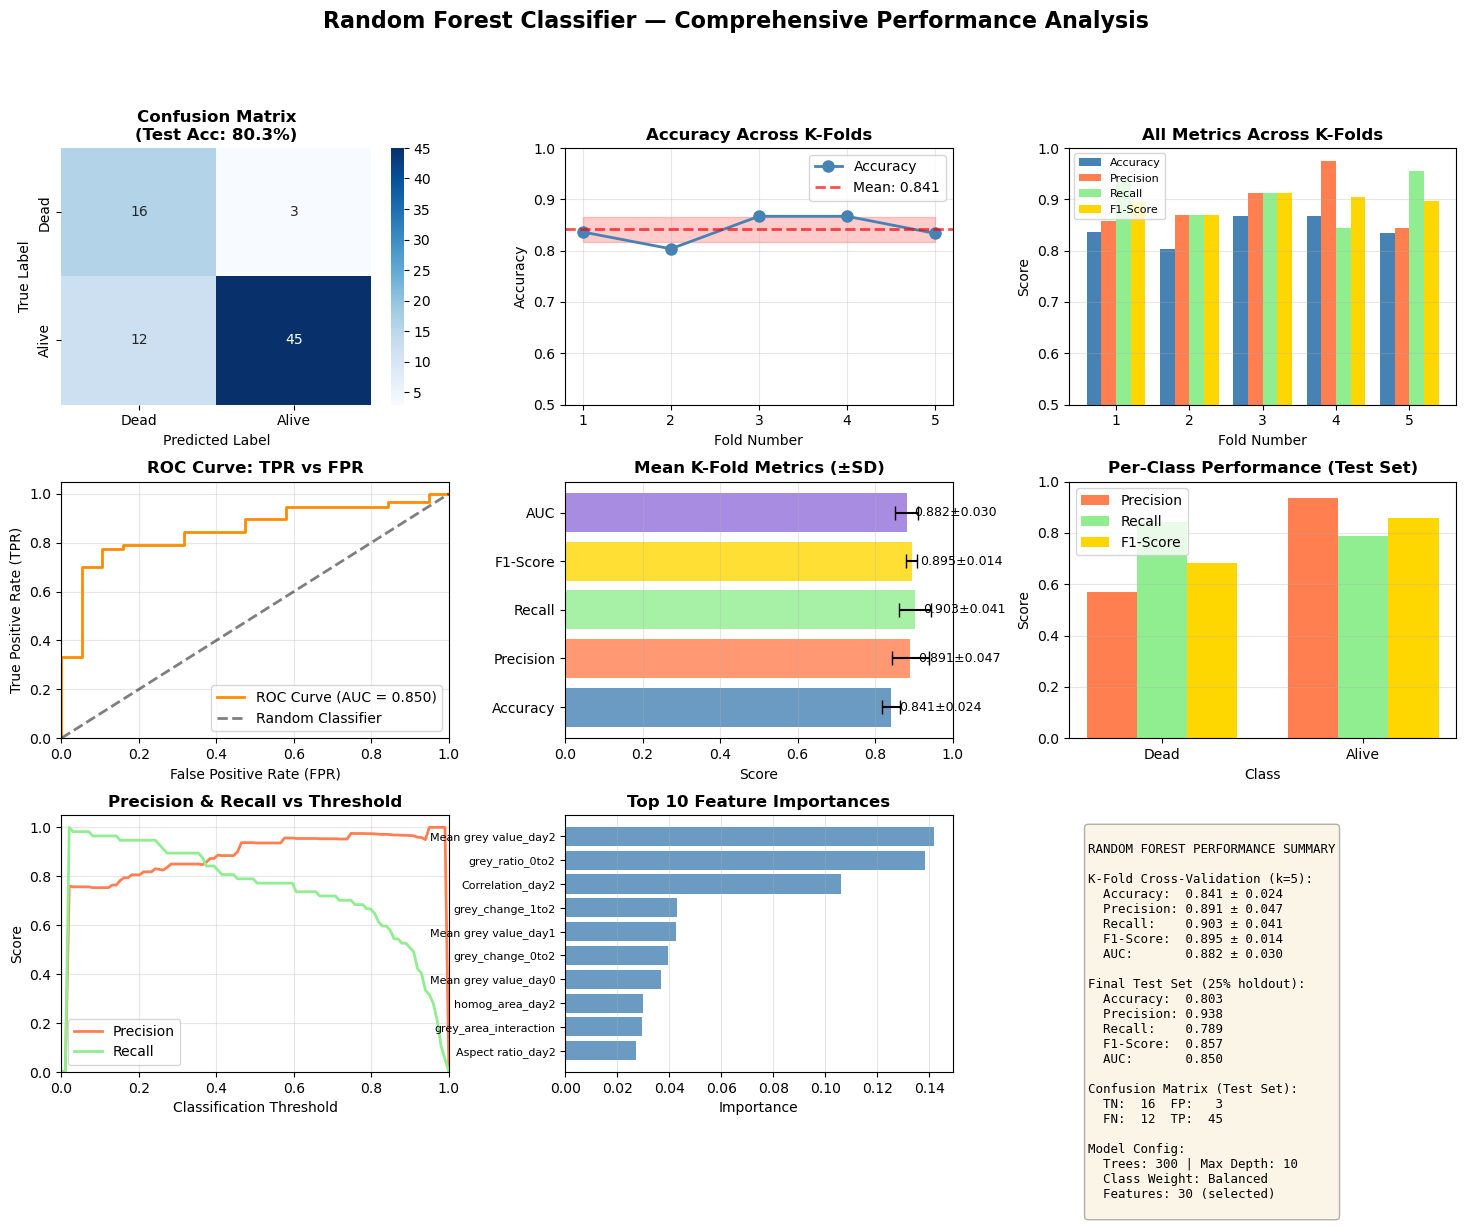

  ✓ RF visualizations complete


In [245]:
print("\n[8/8] Creating RF visualizations...")

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm_final = confusion_matrix(y_test_final, y_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax1.set_title(f'Confusion Matrix\n(Test Acc: {final_acc*100:.1f}%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=10); ax1.set_xlabel('Predicted Label', fontsize=10)

# 2. Per-Fold Accuracy
ax2 = fig.add_subplot(gs[0, 1])
folds = np.arange(1, n_splits+1)
ax2.plot(folds, fold_accuracies, marker='o', linewidth=2, markersize=8, color='steelblue', label='Accuracy')
ax2.axhline(y=np.mean(fold_accuracies), color='red', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Mean: {np.mean(fold_accuracies):.3f}')
ax2.fill_between(folds,
                 np.mean(fold_accuracies) - np.std(fold_accuracies),
                 np.mean(fold_accuracies) + np.std(fold_accuracies),
                 alpha=0.2, color='red')
ax2.set_xlabel('Fold Number', fontsize=10); ax2.set_ylabel('Accuracy', fontsize=10)
ax2.set_title('Accuracy Across K-Folds', fontsize=12, fontweight='bold')
ax2.set_xticks(folds); ax2.grid(True, alpha=0.3); ax2.legend(); ax2.set_ylim([0.5, 1.0])

# 3. All Metrics Across Folds
ax3 = fig.add_subplot(gs[0, 2])
x = np.arange(n_splits); width = 0.2
ax3.bar(x - 1.5*width, fold_accuracies,  width, label='Accuracy',  color='steelblue')
ax3.bar(x - 0.5*width, fold_precisions,  width, label='Precision',  color='coral')
ax3.bar(x + 0.5*width, fold_recalls,     width, label='Recall',     color='lightgreen')
ax3.bar(x + 1.5*width, fold_f1_scores,   width, label='F1-Score',   color='gold')
ax3.set_xlabel('Fold Number', fontsize=10); ax3.set_ylabel('Score', fontsize=10)
ax3.set_title('All Metrics Across K-Folds', fontsize=12, fontweight='bold')
ax3.set_xticks(x); ax3.set_xticklabels([str(i+1) for i in range(n_splits)])
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y'); ax3.set_ylim([0.5, 1.0])

# 4. ROC Curve
ax4 = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test_final, y_proba_final)
ax4.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {final_auc:.3f})', color='darkorange')
ax4.plot([0,1],[0,1],'k--', linewidth=2, label='Random Classifier', alpha=0.5)
ax4.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax4.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax4.set_title('ROC Curve: TPR vs FPR', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right'); ax4.grid(True, alpha=0.3)
ax4.set_xlim([0.0, 1.0]); ax4.set_ylim([0.0, 1.05])

# 5. Mean Metrics Summary
ax5 = fig.add_subplot(gs[1, 1])
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
metrics_values = [np.mean(fold_accuracies), np.mean(fold_precisions), np.mean(fold_recalls),
                  np.mean(fold_f1_scores),  np.mean(fold_auc_scores)]
metrics_stds   = [np.std(fold_accuracies),  np.std(fold_precisions),  np.std(fold_recalls),
                  np.std(fold_f1_scores),   np.std(fold_auc_scores)]
colors = ['steelblue', 'coral', 'lightgreen', 'gold', 'mediumpurple']
ax5.barh(metrics_names, metrics_values, color=colors, alpha=0.8, xerr=metrics_stds, capsize=5)
ax5.set_xlabel('Score', fontsize=10)
ax5.set_title('Mean K-Fold Metrics (±SD)', fontsize=12, fontweight='bold')
ax5.set_xlim([0, 1.0]); ax5.grid(True, alpha=0.3, axis='x')
for i, (val, std) in enumerate(zip(metrics_values, metrics_stds)):
    ax5.text(val + 0.02, i, f'{val:.3f}±{std:.3f}', va='center', fontsize=9)

# 6. Per-Class Performance
ax6 = fig.add_subplot(gs[1, 2])
report = classification_report(y_test_final, y_pred_final,
                               target_names=['Dead', 'Alive'], output_dict=True)
classes = ['Dead', 'Alive']
precision_vals = [report['Dead']['precision'], report['Alive']['precision']]
recall_vals    = [report['Dead']['recall'],    report['Alive']['recall']]
f1_vals        = [report['Dead']['f1-score'],  report['Alive']['f1-score']]
x_pos = np.arange(len(classes)); width = 0.25
ax6.bar(x_pos - width, precision_vals, width, label='Precision', color='coral')
ax6.bar(x_pos,         recall_vals,    width, label='Recall',    color='lightgreen')
ax6.bar(x_pos + width, f1_vals,        width, label='F1-Score',  color='gold')
ax6.set_xlabel('Class', fontsize=10); ax6.set_ylabel('Score', fontsize=10)
ax6.set_title('Per-Class Performance (Test Set)', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos); ax6.set_xticklabels(classes)
ax6.legend(); ax6.grid(True, alpha=0.3, axis='y'); ax6.set_ylim([0, 1.0])

# 7. Precision & Recall vs Threshold
ax7 = fig.add_subplot(gs[2, 0])
precisions_curve, recalls_curve = [], []
thresholds_pr = np.linspace(0, 1, 100)
for thresh in thresholds_pr:
    y_pred_thresh = (y_proba_final >= thresh).astype(int)
    if len(np.unique(y_pred_thresh)) > 1:
        p = precision_score(y_test_final, y_pred_thresh)
        r = recall_score(y_test_final, y_pred_thresh)
    else:
        p, r = 0, 0
    precisions_curve.append(p); recalls_curve.append(r)
ax7.plot(thresholds_pr, precisions_curve, label='Precision', linewidth=2, color='coral')
ax7.plot(thresholds_pr, recalls_curve,    label='Recall',    linewidth=2, color='lightgreen')
ax7.set_xlabel('Classification Threshold', fontsize=10)
ax7.set_ylabel('Score', fontsize=10)
ax7.set_title('Precision & Recall vs Threshold', fontsize=12, fontweight='bold')
ax7.legend(); ax7.grid(True, alpha=0.3); ax7.set_xlim([0,1]); ax7.set_ylim([0,1.05])

# 8. Feature Importance
ax8 = fig.add_subplot(gs[2, 1])
feature_importances = pd.DataFrame({
    'feature':    selected_feature_names,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False).head(10)
ax8.barh(range(len(feature_importances)), feature_importances['importance'],
         color='steelblue', alpha=0.8)
ax8.set_yticks(range(len(feature_importances)))
ax8.set_yticklabels(feature_importances['feature'], fontsize=8)
ax8.set_xlabel('Importance', fontsize=10)
ax8.set_title('Top 10 Feature Importances', fontsize=12, fontweight='bold')
ax8.invert_yaxis(); ax8.grid(True, alpha=0.3, axis='x')

# 9. Summary text
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
summary_text = f"""
RANDOM FOREST PERFORMANCE SUMMARY

K-Fold Cross-Validation (k={n_splits}):
  Accuracy:  {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}
  Precision: {np.mean(fold_precisions):.3f} ± {np.std(fold_precisions):.3f}
  Recall:    {np.mean(fold_recalls):.3f} ± {np.std(fold_recalls):.3f}
  F1-Score:  {np.mean(fold_f1_scores):.3f} ± {np.std(fold_f1_scores):.3f}
  AUC:       {np.mean(fold_auc_scores):.3f} ± {np.std(fold_auc_scores):.3f}

Final Test Set (25% holdout):
  Accuracy:  {final_acc:.3f}
  Precision: {final_prec:.3f}
  Recall:    {final_rec:.3f}
  F1-Score:  {final_f1:.3f}
  AUC:       {final_auc:.3f}

Confusion Matrix (Test Set):
  TN: {cm_final[0,0]:3d}  FP: {cm_final[0,1]:3d}
  FN: {cm_final[1,0]:3d}  TP: {cm_final[1,1]:3d}

Model Config:
  Trees: 300 | Max Depth: 10
  Class Weight: Balanced
  Features: 30 (selected)
"""
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=9,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Random Forest Classifier — Comprehensive Performance Analysis',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()
print("  ✓ RF visualizations complete")


## 8a. Temperature vs Predicted Label — Helper Function & Best-Fold Plot

In [246]:
def plot_temp_vs_predicted(temp_values, pred_labels, title, ax=None, color='steelblue'):
    """Predicted label vs Max Temperature with logistic regression and IC50."""
    from matplotlib.lines import Line2D

    standalone = ax is None
    if standalone:
        fig_out, ax = plt.subplots(figsize=(10, 6))
    else:
        fig_out = ax.get_figure()

    temp_arr = np.array(temp_values, dtype=float)
    pred_arr = np.array(pred_labels)

    mask = ~np.isnan(temp_arr)
    temp_clean = temp_arr[mask]
    pred_clean = pred_arr[mask]

    unique_classes = np.unique(pred_clean)
    if len(unique_classes) < 2 or len(temp_clean) < 2:
        print(f"  Warning: only class(es) {unique_classes} present – skipping logistic fit.")
        ic50 = None
        c_scatter = ['#e74c3c' if p == 0 else '#2ecc71' for p in pred_clean]
        ax.scatter(temp_clean, pred_clean, c=c_scatter, alpha=0.7,
                   edgecolors='black', linewidths=0.4, s=55, zorder=3)
        ax.set_title(title + " (insufficient class diversity)")
        ax.set_ylim(-0.2, 1.2)
        ax.set_xlabel('Max Temperature (°C)'); ax.set_ylabel('Predicted Label')
        return fig_out, ax, ic50

    lr = LogisticRegression(max_iter=1000)
    lr.fit(temp_clean.reshape(-1, 1), pred_clean)
    coef = lr.coef_[0][0]; intercept = lr.intercept_[0]

    ic50 = -intercept / coef if abs(coef) > 1e-9 else None

    t_min, t_max = temp_clean.min() - 1, temp_clean.max() + 1
    temp_range = np.linspace(t_min, t_max, 400)
    lr_proba = lr.predict_proba(temp_range.reshape(-1, 1))[:, 1]

    rng = np.random.default_rng(42)
    # Jitter on both axes so overlapping points (same temperature) spread out visibly
    temp_spread = temp_clean.max() - temp_clean.min()
    x_jitter_scale = max(temp_spread * 0.015, 0.1)   # 1.5% of range, minimum 0.1 °C
    x_jitter = rng.uniform(-x_jitter_scale, x_jitter_scale, size=len(temp_clean))
    y_jitter = rng.uniform(-0.025, 0.025, size=len(pred_clean))

    c_scatter = ['#e74c3c' if p == 0 else '#2ecc71' for p in pred_clean]
    ax.scatter(temp_clean + x_jitter, pred_clean + y_jitter, c=c_scatter, alpha=0.7,
               edgecolors='black', linewidths=0.4, s=55, zorder=3)

    legend_elements = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71',
               markeredgecolor='black', markersize=9, label='Predicted Alive (1)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c',
               markeredgecolor='black', markersize=9, label='Predicted Dead (0)'),
    ]

    ax.plot(temp_range, lr_proba, color=color, linewidth=2.5,
            label=f'Logistic Regression\n(β={coef:.3f}, intercept={intercept:.3f})', zorder=4)

    if ic50 is not None and t_min <= ic50 <= t_max:
        ax.axvline(ic50, color='darkorange', linestyle='--', linewidth=2,
                   label=f'IC50 = {ic50:.2f} °C', zorder=5)
        ax.axhline(0.5, color='grey', linestyle=':', linewidth=1.2, zorder=2)

    ax.set_xlabel('Max Temperature (°C)', fontsize=12)
    ax.set_ylabel('Predicted Label  (0 = Dead, 1 = Alive)', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_yticks([0, 1]); ax.set_yticklabels(['0  (Dead)', '1  (Alive)'])
    ax.set_ylim([-0.15, 1.15]); ax.grid(True, alpha=0.3)

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(
        handles=legend_elements + (handles[-2:] if ic50 is not None else handles[-1:]),
        fontsize=9
    )

    n_dead  = int((pred_clean == 0).sum())
    n_alive = int((pred_clean == 1).sum())
    ic50_str = f'{ic50:.2f} °C' if ic50 is not None else 'N/A (outside range)'
    stats_txt = (f'n = {len(pred_clean)}   |   Dead = {n_dead}   Alive = {n_alive}\n'
                 f'IC50 = {ic50_str}')
    ax.text(0.02, 0.97, stats_txt, transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    if standalone:
        plt.tight_layout()

    return fig_out, ax, ic50



[8a/8] Best-fold temperature plot...
  Best fold: Fold 3 (Accuracy = 0.8667)


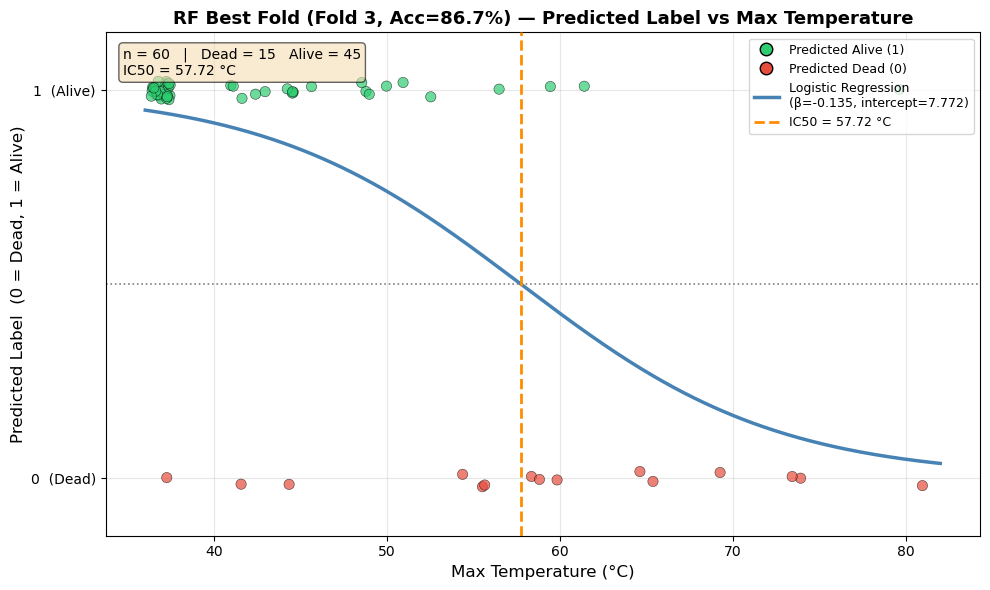

  ✓ IC50 = 57.72 °C


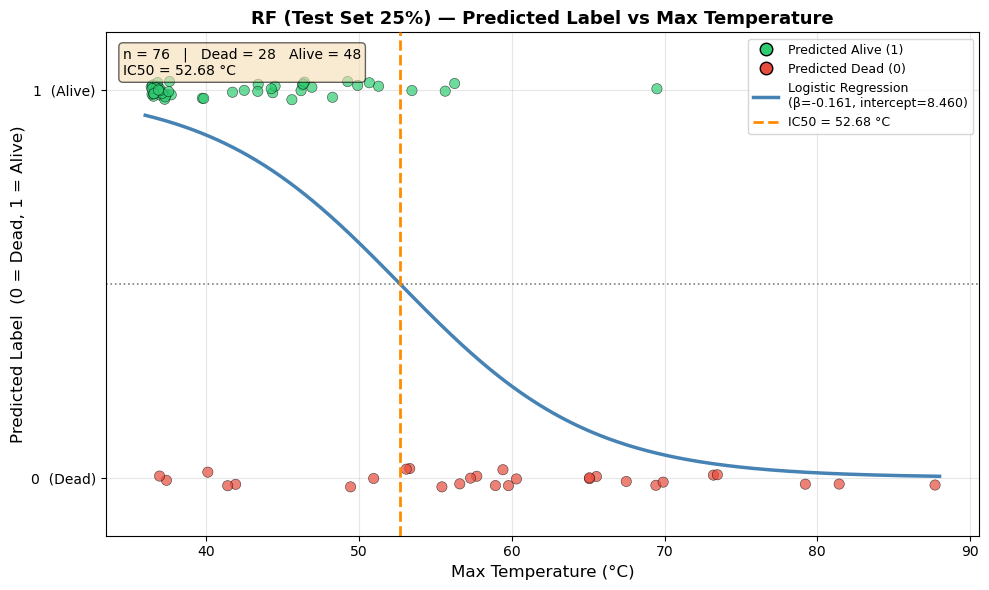

  ✓ IC50 = 52.68 °C


In [247]:
print("\n[8a/8] Best-fold temperature plot...")

best_fold_idx = int(np.argmax(fold_accuracies))
best_fold_num = best_fold_idx + 1
print(f"  Best fold: Fold {best_fold_num} (Accuracy = {fold_accuracies[best_fold_idx]:.4f})")

if MAX_TEMP_COL not in df_complete.columns:
    print(f"  WARNING: '{MAX_TEMP_COL}' not found – skipping temperature plots.")
else:
    # --- Best-fold plot (validation indices from training data) ---
    best_val_idx  = fold_val_indices[best_fold_idx]
    best_y_pred   = fold_val_predictions[best_fold_idx]
    best_max_temp = df_complete.iloc[best_val_idx][MAX_TEMP_COL].values.astype(float)

    fig_bf, _, ic50_bf = plot_temp_vs_predicted(
        best_max_temp, best_y_pred,
        title=(f'RF Best Fold (Fold {best_fold_num}, Acc={fold_accuracies[best_fold_idx]*100:.1f}%) '
               f'— Predicted Label vs Max Temperature'),
        color='steelblue'
    )
    plt.show()
    print(f"  ✓ IC50 = {f'{ic50_bf:.2f} °C' if ic50_bf is not None else 'outside data range'}")

    # --- RF test-set plot ---
    # In cross-dataset mode _test_pos indexes into _df_test (the external CSV).
    # In normal mode _test_pos indexes into df_complete (the 25 % hold-out split).
    _temp_src = _df_test if CROSS_DATASET_MODE else df_complete

    if MAX_TEMP_COL in _temp_src.columns:
        rf_test_max_temp = _temp_src.iloc[_test_pos][MAX_TEMP_COL].values.astype(float)
        test_title = (f'RF ({"External Test: " + Path(TEST_CSV).name if CROSS_DATASET_MODE else "Test Set 25%"})'
                      f' — Predicted Label vs Max Temperature')
        fig_rf_t, _, ic50_rf = plot_temp_vs_predicted(
            rf_test_max_temp, y_pred_final,
            title=test_title,
            color='steelblue'
        )
        plt.show()
        print(f"  ✓ IC50 = {f'{ic50_rf:.2f} °C' if ic50_rf is not None else 'outside data range'}")
    else:
        ic50_rf = None
        print(f"  WARNING: '{MAX_TEMP_COL}' not found in test data.")


## 8b. Neural Network — Training & Evaluation

In [248]:
print("\n[8b/8] Training Neural Network...")
from tensorflow.keras.regularizers import l2 as keras_l2

num_classes = 2
size = X_train_final_scaled.shape[1]

# One-hot encode labels for categorical cross-entropy (e.g. 1 → [0,1], 0 → [1,0])
y_train_nn = tf.keras.utils.to_categorical(y_train_final, num_classes)
y_test_nn  = tf.keras.utils.to_categorical(y_test_final,  num_classes)

# L2 regularization penalises large weights — helps generalisation
_reg = keras_l2(L2_REG) if L2_REG > 0 else None

# Build model — Dropout layers are inserted only when DROPOUT_RATE > 0
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(size,)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=_reg),
    *([ tf.keras.layers.Dropout(DROPOUT_RATE) ] if DROPOUT_RATE > 0 else []),
    tf.keras.layers.Dense(10,  activation='relu', kernel_regularizer=_reg),
    *([ tf.keras.layers.Dropout(DROPOUT_RATE) ] if DROPOUT_RATE > 0 else []),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # output: P(Dead), P(Alive)
])
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping monitors val_loss and restores the best weights when it stops improving
callbacks = []
if EARLY_STOPPING:
    callbacks.append(tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True, verbose=1
    ))

# When early stopping is on, allow up to 100 epochs; otherwise fix at 30
history = model.fit(
    X_train_final_scaled, y_train_nn,
    epochs=100 if EARLY_STOPPING else 30,
    batch_size=32, validation_split=0.1,   # 10% of training data used for validation
    callbacks=callbacks, verbose=0
)

nn_proba       = model.predict(X_test_final_scaled, verbose=0)
nn_pred        = np.argmax(nn_proba, axis=1)       # class with highest probability
nn_proba_alive = nn_proba[:, 1]                    # P(Alive) for ROC/AUC

nn_acc  = accuracy_score(y_test_final, nn_pred)
nn_prec = precision_score(y_test_final, nn_pred)
nn_rec  = recall_score(y_test_final, nn_pred)
nn_f1   = f1_score(y_test_final, nn_pred)
nn_auc  = roc_auc_score(y_test_final, nn_proba_alive)

epochs_run = len(history.history['loss'])
print(f"\n  Epochs run     : {epochs_run} {'(early stopped)' if EARLY_STOPPING and epochs_run < 100 else ''}")
print(f"  Dropout        : {DROPOUT_RATE}")
print(f"  L2 reg         : {L2_REG}")
print(f"\n  NEURAL NETWORK TEST PERFORMANCE:")
print(f"  Accuracy:  {nn_acc:.4f}")
print(f"  Precision: {nn_prec:.4f}")
print(f"  Recall:    {nn_rec:.4f}")
print(f"  F1-Score:  {nn_f1:.4f}")
print(f"  ROC AUC:   {nn_auc:.4f}")
print(f"\n  Winner: {'Random Forest' if final_acc > nn_acc else 'Neural Network' if nn_acc > final_acc else 'Tie'} (Accuracy)")


[8b/8] Training Neural Network...
Epoch 10: early stopping
Restoring model weights from the end of the best epoch: 5.

  Epochs run     : 10 (early stopped)
  Dropout        : 0.3
  L2 reg         : 0.001

  NEURAL NETWORK TEST PERFORMANCE:
  Accuracy:  0.8158
  Precision: 0.8413
  Recall:    0.9298
  F1-Score:  0.8833
  ROC AUC:   0.8800

  Winner: Neural Network (Accuracy)


## 8b-ii. Neural Network — 5-Fold Cross-Validation

In [249]:
print("\n[8b-ii] NN 5-Fold Cross-Validation (same splits as RF)...")

nn_fold_accuracies,      nn_fold_precisions, nn_fold_recalls = [], [], []
nn_fold_f1_scores,       nn_fold_auc_scores                  = [], []
nn_fold_train_accuracies = []   # for overfitting analysis

nn_oof_pred  = np.full(len(df_complete), np.nan)
nn_oof_proba = np.full(len(df_complete), np.nan)

for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X_selected, y), 1):
    X_tr, X_vl = X_selected[train_idx], X_selected[val_idx]
    y_tr, y_vl = y.iloc[train_idx],    y.iloc[val_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_vl_s = sc.transform(X_vl)

    _reg_fold = keras_l2(L2_REG) if L2_REG > 0 else None

    nn_fold = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_tr_s.shape[1],)),
        tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=_reg_fold),
        *([ tf.keras.layers.Dropout(DROPOUT_RATE) ] if DROPOUT_RATE > 0 else []),
        tf.keras.layers.Dense(10,  activation='relu', kernel_regularizer=_reg_fold),
        *([ tf.keras.layers.Dropout(DROPOUT_RATE) ] if DROPOUT_RATE > 0 else []),
        tf.keras.layers.Dense(2,   activation='softmax'),
    ])
    nn_fold.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

    fold_callbacks = []
    if EARLY_STOPPING:
        fold_callbacks.append(tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True, verbose=0
        ))

    nn_fold.fit(
        X_tr_s, tf.keras.utils.to_categorical(y_tr, 2),
        epochs=100 if EARLY_STOPPING else 30,
        batch_size=32, validation_split=0.1,
        callbacks=fold_callbacks, verbose=0
    )

    nn_proba_fold = nn_fold.predict(X_vl_s, verbose=0)
    nn_pred_fold  = np.argmax(nn_proba_fold, axis=1)
    nn_prob_alive = nn_proba_fold[:, 1]

    # Train accuracy for overfitting check
    nn_pred_train_fold = np.argmax(nn_fold.predict(X_tr_s, verbose=0), axis=1)
    nn_fold_train_accuracies.append(accuracy_score(y_tr, nn_pred_train_fold))

    nn_fold_accuracies.append(accuracy_score(y_vl, nn_pred_fold))
    nn_fold_precisions.append(precision_score(y_vl, nn_pred_fold, zero_division=0))
    nn_fold_recalls.append(recall_score(y_vl, nn_pred_fold, zero_division=0))
    nn_fold_f1_scores.append(f1_score(y_vl, nn_pred_fold, zero_division=0))
    nn_fold_auc_scores.append(roc_auc_score(y_vl, nn_prob_alive))

    nn_oof_pred[val_idx]  = nn_pred_fold
    nn_oof_proba[val_idx] = nn_prob_alive

    gap_nn = nn_fold_train_accuracies[-1] - nn_fold_accuracies[-1]
    print(f"    Fold {fold_idx}: TrainAcc={nn_fold_train_accuracies[-1]:.4f}  ValAcc={nn_fold_accuracies[-1]:.4f}  "
          f"Gap={gap_nn:+.4f}  F1={nn_fold_f1_scores[-1]:.4f}  AUC={nn_fold_auc_scores[-1]:.4f}")

print(f"  NN Mean Accuracy: {np.mean(nn_fold_accuracies):.4f} ± {np.std(nn_fold_accuracies):.4f}")


[8b-ii] NN 5-Fold Cross-Validation (same splits as RF)...
    Fold 1: TrainAcc=0.9253  ValAcc=0.8197  Gap=+0.1056  F1=0.8817  AUC=0.8500
    Fold 2: TrainAcc=0.8838  ValAcc=0.8689  Gap=+0.0150  F1=0.9130  AUC=0.8739
    Fold 3: TrainAcc=0.9256  ValAcc=0.8000  Gap=+0.1256  F1=0.8723  AUC=0.8607
    Fold 4: TrainAcc=0.8926  ValAcc=0.9000  Gap=-0.0074  F1=0.9302  AUC=0.9378
    Fold 5: TrainAcc=0.8719  ValAcc=0.8500  Gap=+0.0219  F1=0.9032  AUC=0.8800
  NN Mean Accuracy: 0.8477 ± 0.0354


## 8b-iii. Overfitting Analysis — Neural Network & RF vs NN Comparison


[8b-iii] Overfitting Analysis — NN & RF vs NN comparison

  NN Overfitting Summary:
  Fold | Train Acc |  Val Acc |     Gap
  ----------------------------------------
     1 |    0.9253 |   0.8197 | +0.1056  ← overfit?
     2 |    0.8838 |   0.8689 | +0.0150
     3 |    0.9256 |   0.8000 | +0.1256  ← overfit?
     4 |    0.8926 |   0.9000 | -0.0074
     5 |    0.8719 |   0.8500 | +0.0219

  Mean gap: +0.0521  (✓ OK)


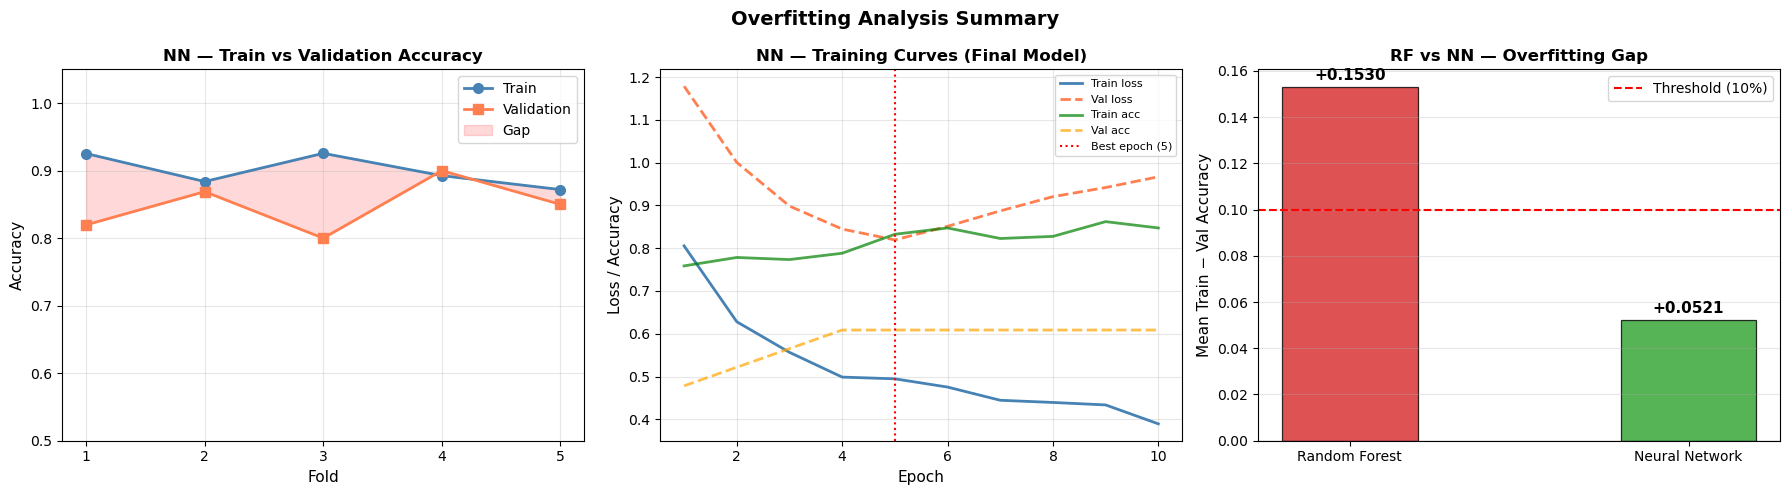


  Summary:
  RF  mean gap : +0.1530  (⚠ overfit)
  NN  mean gap : +0.0521  (✓ OK)

  Regularization applied to NN:
    Early stopping : True  (patience=5, stopped at epoch 5)
    Dropout rate   : 0.3
    L2 reg         : 0.001


In [250]:
print("\n[8b-iii] Overfitting Analysis — NN & RF vs NN comparison")

nn_gaps     = [tr - val for tr, val in zip(nn_fold_train_accuracies, nn_fold_accuracies)]
nn_mean_gap = np.mean(nn_gaps)
nn_overfit  = nn_mean_gap > OVERFIT_THRESHOLD

# ── NN gap table ─────────────────────────────────────────────────────────────
print(f"\n  NN Overfitting Summary:")
print(f"  {'Fold':>4} | {'Train Acc':>9} | {'Val Acc':>8} | {'Gap':>7}")
print("  " + "-"*40)
for i, (tr, val, g) in enumerate(zip(nn_fold_train_accuracies, nn_fold_accuracies, nn_gaps), 1):
    flag = "  ← overfit?" if g > OVERFIT_THRESHOLD else ""
    print(f"  {i:4d} | {tr:9.4f} | {val:8.4f} | {g:+.4f}{flag}")
print(f"\n  Mean gap: {nn_mean_gap:+.4f}  ({'⚠ OVERFITTING' if nn_overfit else '✓ OK'})")

# ── Combined figure ───────────────────────────────────────────────────────────
fig_ov2, axes_ov2 = plt.subplots(1, 3, figsize=(18, 5))

# 1. NN train vs val per fold
ax1 = axes_ov2[0]
ax1.plot(folds, nn_fold_train_accuracies, 'o-', color='steelblue', linewidth=2, markersize=7, label='Train')
ax1.plot(folds, nn_fold_accuracies,       's-', color='coral',     linewidth=2, markersize=7, label='Validation')
ax1.fill_between(folds, nn_fold_train_accuracies, nn_fold_accuracies, alpha=0.15, color='red', label='Gap')
ax1.set_xlabel('Fold', fontsize=11); ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('NN — Train vs Validation Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticks(folds); ax1.set_ylim([0.5, 1.05])
ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. Train/val loss from final NN training (early stopping view)
ax2 = axes_ov2[1]
ep = np.arange(1, len(history.history['loss']) + 1)
ax2.plot(ep, history.history['loss'],     color='steelblue', linewidth=2, label='Train loss')
ax2.plot(ep, history.history['val_loss'], color='coral',     linewidth=2, label='Val loss',   linestyle='--')
ax2.plot(ep, history.history['accuracy'],     color='green',   linewidth=2, label='Train acc',  linestyle='-',  alpha=0.7)
ax2.plot(ep, history.history['val_accuracy'], color='orange',  linewidth=2, label='Val acc',    linestyle='--', alpha=0.7)
best_ep = int(np.argmin(history.history['val_loss'])) + 1
ax2.axvline(best_ep, color='red', linestyle=':', linewidth=1.5, label=f'Best epoch ({best_ep})')
ax2.set_xlabel('Epoch', fontsize=11); ax2.set_ylabel('Loss / Accuracy', fontsize=11)
ax2.set_title('NN — Training Curves (Final Model)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# 3. RF vs NN mean gap comparison
ax3 = axes_ov2[2]
models_cmp   = ['Random Forest', 'Neural Network']
gaps_cmp     = [mean_gap, nn_mean_gap]
colors_cmp   = ['#d62728' if g > OVERFIT_THRESHOLD else '#2ca02c' for g in gaps_cmp]
bars3 = ax3.bar(models_cmp, gaps_cmp, color=colors_cmp, alpha=0.8, edgecolor='black', linewidth=0.9, width=0.4)
ax3.axhline(OVERFIT_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Threshold ({OVERFIT_THRESHOLD:.0%})')
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylabel('Mean Train − Val Accuracy', fontsize=11)
ax3.set_title('RF vs NN — Overfitting Gap', fontsize=12, fontweight='bold')
ax3.legend(); ax3.grid(True, alpha=0.3, axis='y')
for bar, g in zip(bars3, gaps_cmp):
    ax3.text(bar.get_x() + bar.get_width()/2, g + 0.003, f'{g:+.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Overfitting Analysis Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n  Summary:")
print(f"  RF  mean gap : {mean_gap:+.4f}  ({'⚠ overfit' if overfit_flag else '✓ OK'})")
print(f"  NN  mean gap : {nn_mean_gap:+.4f}  ({'⚠ overfit' if nn_overfit else '✓ OK'})")
print(f"\n  Regularization applied to NN:")
print(f"    Early stopping : {EARLY_STOPPING}  (patience={EARLY_STOPPING_PATIENCE}, stopped at epoch {best_ep})")
print(f"    Dropout rate   : {DROPOUT_RATE}")
print(f"    L2 reg         : {L2_REG}")

## 8c. Neural Network — Comprehensive Visualizations


[8c/8] Neural Network visualizations...


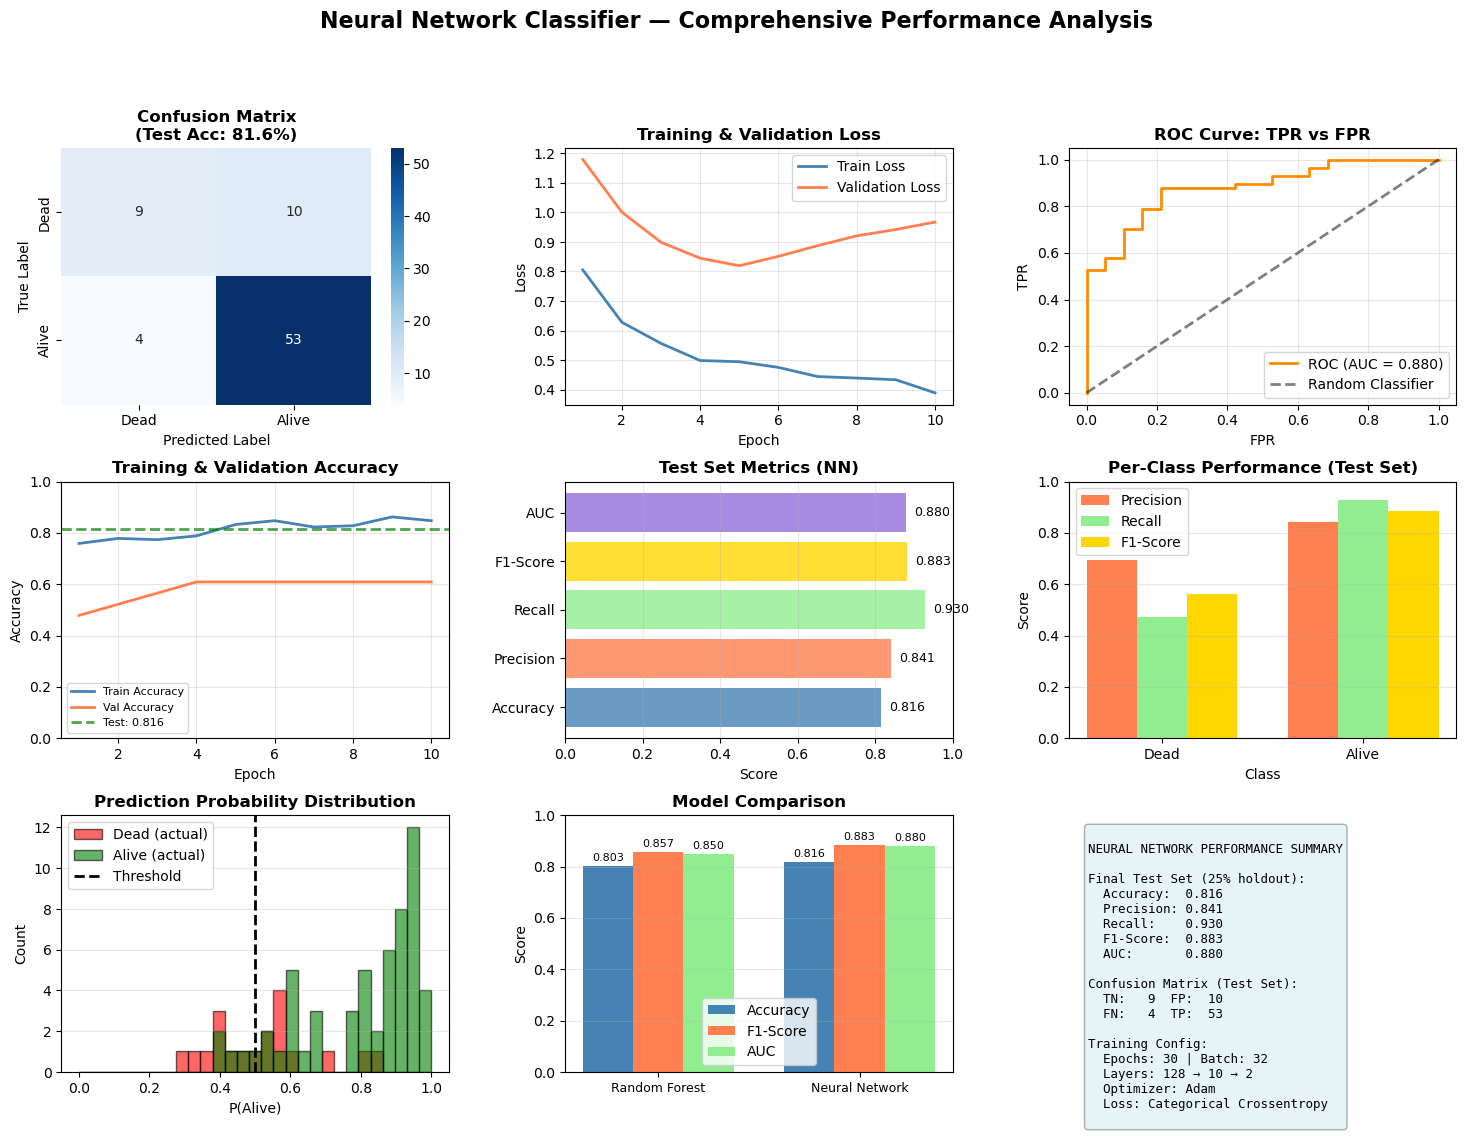

  ✓ NN visualizations complete


In [251]:
print("\n[8c/8] Neural Network visualizations...")

fig_nn = plt.figure(figsize=(18, 12))
gs_nn  = fig_nn.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1_nn = fig_nn.add_subplot(gs_nn[0, 0])
cm_nn = confusion_matrix(y_test_final, nn_pred)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', ax=ax1_nn,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax1_nn.set_title(f'Confusion Matrix\n(Test Acc: {nn_acc*100:.1f}%)', fontsize=12, fontweight='bold')
ax1_nn.set_ylabel('True Label', fontsize=10); ax1_nn.set_xlabel('Predicted Label', fontsize=10)

# 2. Training Loss
ax2_nn = fig_nn.add_subplot(gs_nn[0, 1])
epochs_range = np.arange(1, len(history.history['loss']) + 1)
ax2_nn.plot(epochs_range, history.history['loss'],     label='Train Loss',      linewidth=2, color='steelblue')
ax2_nn.plot(epochs_range, history.history['val_loss'], label='Validation Loss', linewidth=2, color='coral')
ax2_nn.set_xlabel('Epoch', fontsize=10); ax2_nn.set_ylabel('Loss', fontsize=10)
ax2_nn.set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
ax2_nn.legend(); ax2_nn.grid(True, alpha=0.3)

# 3. ROC Curve
ax3_nn = fig_nn.add_subplot(gs_nn[0, 2])
fpr_nn, tpr_nn, _ = roc_curve(y_test_final, nn_proba_alive)
ax3_nn.plot(fpr_nn, tpr_nn, linewidth=2, label=f'ROC (AUC = {nn_auc:.3f})', color='darkorange')
ax3_nn.plot([0,1],[0,1],'k--', linewidth=2, alpha=0.5, label='Random Classifier')
ax3_nn.set_xlabel('FPR', fontsize=10); ax3_nn.set_ylabel('TPR', fontsize=10)
ax3_nn.set_title('ROC Curve: TPR vs FPR', fontsize=12, fontweight='bold')
ax3_nn.legend(loc='lower right'); ax3_nn.grid(True, alpha=0.3)

# 4. Training Accuracy
ax4_nn = fig_nn.add_subplot(gs_nn[1, 0])
ax4_nn.plot(epochs_range, history.history['accuracy'],     label='Train Accuracy',  linewidth=2, color='steelblue')
ax4_nn.plot(epochs_range, history.history['val_accuracy'], label='Val Accuracy',    linewidth=2, color='coral')
ax4_nn.axhline(y=nn_acc, color='green', linestyle='--', linewidth=2, alpha=0.7,
               label=f'Test: {nn_acc:.3f}')
ax4_nn.set_xlabel('Epoch', fontsize=10); ax4_nn.set_ylabel('Accuracy', fontsize=10)
ax4_nn.set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
ax4_nn.legend(fontsize=8); ax4_nn.grid(True, alpha=0.3); ax4_nn.set_ylim([0, 1.0])

# 5. Metrics bar
ax5_nn = fig_nn.add_subplot(gs_nn[1, 1])
nn_metrics = [nn_acc, nn_prec, nn_rec, nn_f1, nn_auc]
colors_nn  = ['steelblue', 'coral', 'lightgreen', 'gold', 'mediumpurple']
bars = ax5_nn.barh(metrics_names, nn_metrics, color=colors_nn, alpha=0.8)
ax5_nn.set_xlabel('Score', fontsize=10)
ax5_nn.set_title('Test Set Metrics (NN)', fontsize=12, fontweight='bold')
ax5_nn.set_xlim([0, 1.0]); ax5_nn.grid(True, alpha=0.3, axis='x')
for i, (bar, val) in enumerate(zip(bars, nn_metrics)):
    ax5_nn.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

# 6. Per-Class Performance
ax6_nn = fig_nn.add_subplot(gs_nn[1, 2])
report_nn = classification_report(y_test_final, nn_pred,
                                  target_names=['Dead', 'Alive'], output_dict=True)
precision_vals_nn = [report_nn['Dead']['precision'], report_nn['Alive']['precision']]
recall_vals_nn    = [report_nn['Dead']['recall'],    report_nn['Alive']['recall']]
f1_vals_nn        = [report_nn['Dead']['f1-score'],  report_nn['Alive']['f1-score']]
x_pos = np.arange(2); width = 0.25
ax6_nn.bar(x_pos - width, precision_vals_nn, width, label='Precision', color='coral')
ax6_nn.bar(x_pos,         recall_vals_nn,    width, label='Recall',    color='lightgreen')
ax6_nn.bar(x_pos + width, f1_vals_nn,        width, label='F1-Score',  color='gold')
ax6_nn.set_xlabel('Class', fontsize=10); ax6_nn.set_ylabel('Score', fontsize=10)
ax6_nn.set_title('Per-Class Performance (Test Set)', fontsize=12, fontweight='bold')
ax6_nn.set_xticks(x_pos); ax6_nn.set_xticklabels(['Dead', 'Alive'])
ax6_nn.legend(); ax6_nn.grid(True, alpha=0.3, axis='y'); ax6_nn.set_ylim([0, 1.0])

# 7. Prediction Distribution
ax7_nn = fig_nn.add_subplot(gs_nn[2, 0])
bins = np.linspace(0, 1, 30)
ax7_nn.hist(nn_proba_alive[y_test_final==0], bins=bins, alpha=0.6, label='Dead (actual)',  color='red',   edgecolor='black')
ax7_nn.hist(nn_proba_alive[y_test_final==1], bins=bins, alpha=0.6, label='Alive (actual)', color='green', edgecolor='black')
ax7_nn.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
ax7_nn.set_xlabel('P(Alive)', fontsize=10); ax7_nn.set_ylabel('Count', fontsize=10)
ax7_nn.set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
ax7_nn.legend(); ax7_nn.grid(True, alpha=0.3, axis='y')

# 8. RF vs NN Comparison
ax8_nn = fig_nn.add_subplot(gs_nn[2, 1])
df_models = pd.DataFrame({'Model': ['Random Forest', 'Neural Network'],
                          'Accuracy': [final_acc, nn_acc],
                          'F1-Score': [final_f1, nn_f1],
                          'AUC':      [final_auc, nn_auc]})
x = np.arange(len(df_models)); width = 0.25
ax8_nn.bar(x - width, df_models['Accuracy'], width, label='Accuracy', color='steelblue')
ax8_nn.bar(x,         df_models['F1-Score'], width, label='F1-Score', color='coral')
ax8_nn.bar(x + width, df_models['AUC'],      width, label='AUC',      color='lightgreen')
ax8_nn.set_ylabel('Score', fontsize=10); ax8_nn.set_title('Model Comparison', fontsize=12, fontweight='bold')
ax8_nn.set_xticks(x); ax8_nn.set_xticklabels(df_models['Model'], fontsize=9)
ax8_nn.legend(); ax8_nn.grid(True, alpha=0.3, axis='y'); ax8_nn.set_ylim([0, 1.0])
for i, row in df_models.iterrows():
    ax8_nn.text(i - width, row['Accuracy'] + 0.02, f"{row['Accuracy']:.3f}", ha='center', fontsize=8)
    ax8_nn.text(i,         row['F1-Score'] + 0.02, f"{row['F1-Score']:.3f}", ha='center', fontsize=8)
    ax8_nn.text(i + width, row['AUC']      + 0.02, f"{row['AUC']:.3f}",      ha='center', fontsize=8)

# 9. Summary text
ax9_nn = fig_nn.add_subplot(gs_nn[2, 2])
ax9_nn.axis('off')
summary_nn = f"""
NEURAL NETWORK PERFORMANCE SUMMARY

Final Test Set (25% holdout):
  Accuracy:  {nn_acc:.3f}
  Precision: {nn_prec:.3f}
  Recall:    {nn_rec:.3f}
  F1-Score:  {nn_f1:.3f}
  AUC:       {nn_auc:.3f}

Confusion Matrix (Test Set):
  TN: {cm_nn[0,0]:3d}  FP: {cm_nn[0,1]:3d}
  FN: {cm_nn[1,0]:3d}  TP: {cm_nn[1,1]:3d}

Training Config:
  Epochs: 30 | Batch: 32
  Layers: 128 → 10 → 2
  Optimizer: Adam
  Loss: Categorical Crossentropy
"""
ax9_nn.text(0.05, 0.95, summary_nn, transform=ax9_nn.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.suptitle('Neural Network Classifier — Comprehensive Performance Analysis',
             fontsize=16, fontweight='bold', y=0.995)
plt.show()
print("  ✓ NN visualizations complete")


## 8d. Neural Network — Temperature vs Predicted Label

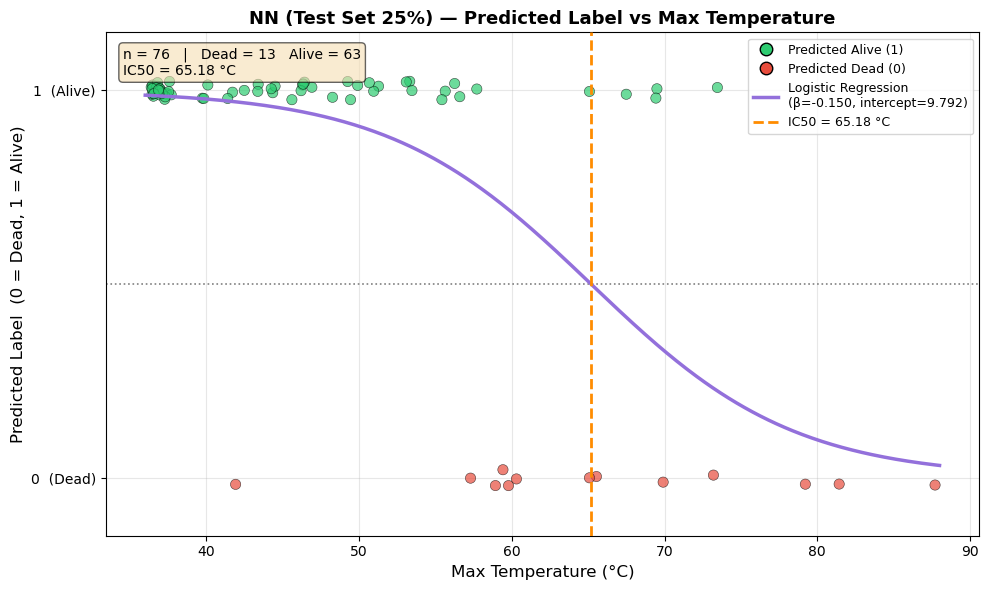

  ✓ IC50 = 65.18 °C


In [252]:
_temp_src = _df_test if CROSS_DATASET_MODE else df_complete

if MAX_TEMP_COL in _temp_src.columns:
    nn_test_max_temp = _temp_src.iloc[_test_pos][MAX_TEMP_COL].values.astype(float)
    nn_test_title = (f'NN ({"External Test: " + Path(TEST_CSV).name if CROSS_DATASET_MODE else "Test Set 25%"})'
                     f' — Predicted Label vs Max Temperature')
    fig_nn_t, _, ic50_nn = plot_temp_vs_predicted(
        nn_test_max_temp, nn_pred,
        title=nn_test_title,
        color='mediumpurple'
    )
    plt.show()
    print(f"  ✓ IC50 = {f'{ic50_nn:.2f} °C' if ic50_nn is not None else 'outside data range'}")
else:
    ic50_nn = None
    print(f"  WARNING: '{MAX_TEMP_COL}' not found in test data.")


## 9. Violin Plot — Temperature by Predicted / True Label


[9] Violin plot: Temperature by Predicted / True Label...


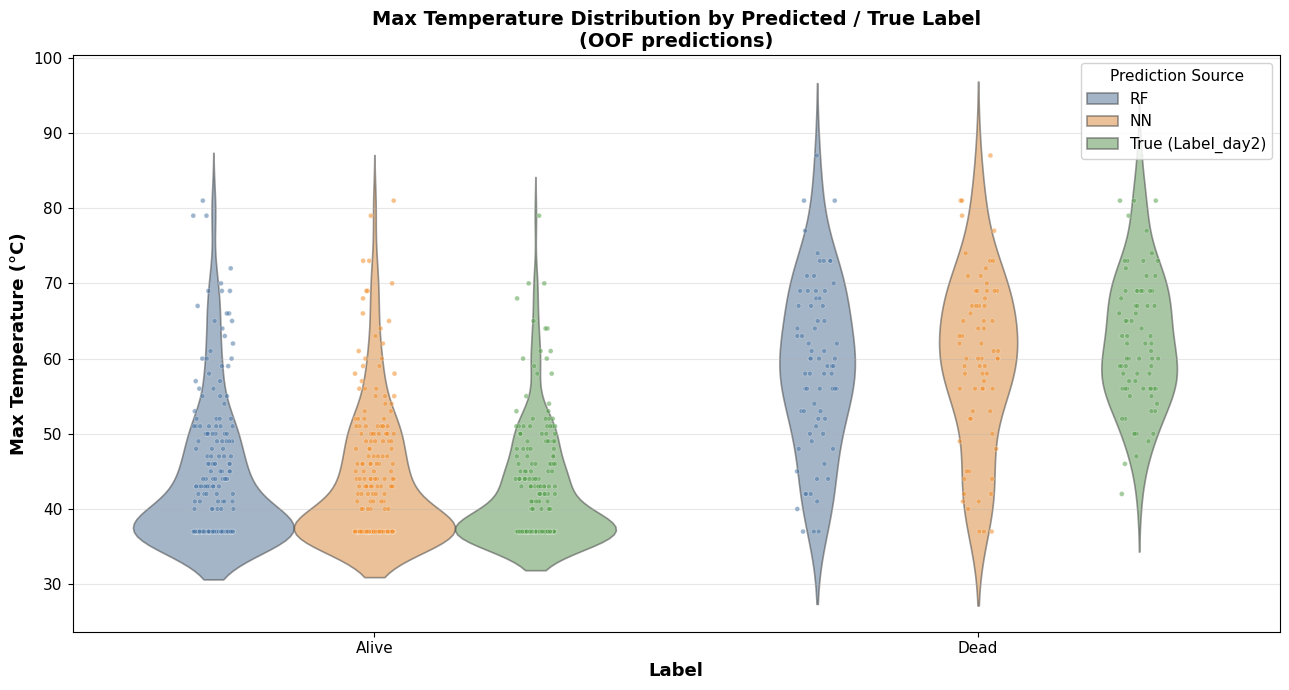

  ✓ Violin plot saved → F:\Experiments\PTT\Spheroids\all data\mcf7\violin_temperature_labels.png


In [253]:
print("\n[9] Violin plot: Temperature by Predicted / True Label...")

# OOF predictions are always from the training dataset
rf_label_all   = pd.Series(rf_oof_pred, index=df_complete.index).map({1.0: 'Alive', 0.0: 'Dead'})
nn_label_all   = pd.Series(nn_oof_pred, index=df_complete.index).map({1.0: 'Alive', 0.0: 'Dead'})
true_label_all = df_complete['Label_day2'].str.strip()   # ground-truth label from the dataset

if MAX_TEMP_COL not in df_complete.columns:
    print(f"  WARNING: '{MAX_TEMP_COL}' not found in training data.")
else:
    temp_all = df_complete[MAX_TEMP_COL].values.astype(float)

    rows_violin = []
    for rf_l, nn_l, true_l, temp in zip(rf_label_all, nn_label_all, true_label_all, temp_all):
        if not np.isnan(temp):
            rows_violin.append({'Source': 'RF',          'Label': rf_l,   'Temperature': temp})
            rows_violin.append({'Source': 'NN',          'Label': nn_l,   'Temperature': temp})
            rows_violin.append({'Source': 'True (Label_day2)', 'Label': true_l, 'Temperature': temp})

    violin_df = pd.DataFrame(rows_violin)

    palette_violin   = {'RF': '#4e79a7', 'NN': '#f28e2b', 'True (Label_day2)': '#59a14f'}
    hue_order_violin = ['RF', 'NN', 'True (Label_day2)']
    label_order_violin = ['Alive', 'Dead']

    fig_violin, ax_violin = plt.subplots(figsize=(13, 7))

    sns.violinplot(
        data=violin_df, x='Label', y='Temperature', hue='Source',
        order=label_order_violin, hue_order=hue_order_violin,
        ax=ax_violin, palette=palette_violin,
        inner=None, alpha=0.55, linewidth=1.2
    )
    sns.stripplot(
        data=violin_df, x='Label', y='Temperature', hue='Source',
        order=label_order_violin, hue_order=hue_order_violin,
        ax=ax_violin, palette=palette_violin,
        dodge=True, jitter=True, alpha=0.55, size=3.5,
        linewidth=0.3, edgecolor='white', legend=False
    )

    handles, labels_leg = ax_violin.get_legend_handles_labels()
    ax_violin.legend(handles[:3], labels_leg[:3],
                     title='Prediction Source', fontsize=11, title_fontsize=11,
                     loc='upper right', framealpha=0.85)

    dataset_note = f"(Train: {Path(TRAIN_CSV).name} — OOF)" if CROSS_DATASET_MODE else "(OOF predictions)"
    ax_violin.set_xlabel('Label',                fontsize=13, fontweight='bold')
    ax_violin.set_ylabel('Max Temperature (°C)', fontsize=13, fontweight='bold')
    ax_violin.set_title(
        f'Max Temperature Distribution by Predicted / True Label\n{dataset_note}',
        fontsize=14, fontweight='bold'
    )
    ax_violin.grid(True, alpha=0.3, axis='y')
    ax_violin.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    violin_path = OUTPUT_DIR / 'violin_temperature_labels.png'
    plt.savefig(violin_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✓ Violin plot saved → {violin_path}")


## 10. CSV Export — OOF Predictions

In [254]:
print("\n[10] Exporting CSV with predictions...")

if CROSS_DATASET_MODE:
    # Export predictions made on the external test dataset
    df_export = df_complete_test.copy()
    df_export['RF_Prediction'] = pd.Series(
        np.where(y_pred_final == 1, 'Alive', 'Dead'), index=df_complete_test.index
    )
    df_export['NN_Prediction'] = pd.Series(
        np.where(nn_pred == 1, 'Alive', 'Dead'), index=df_complete_test.index
    )
    csv_export_path = OUTPUT_DIR / f'predictions_export_crossdataset_{Path(TEST_CSV).stem}.csv'
else:
    # Export out-of-fold (OOF) predictions — each row was predicted by a fold
    # that never saw it during training, making these unbiased estimates
    df_export = df_complete.copy()
    df_export['RF_Prediction'] = rf_label_all.values
    df_export['NN_Prediction'] = nn_label_all.values
    csv_export_path = OUTPUT_DIR / 'predictions_export.csv'

df_export.to_csv(csv_export_path)
print(f"  ✓ CSV saved → {csv_export_path}  ({df_export.shape[0]} rows × {df_export.shape[1]} cols)")
print(f"  New columns: RF_Prediction, NN_Prediction")


[10] Exporting CSV with predictions...
  ✓ CSV saved → F:\Experiments\PTT\Spheroids\all data\mcf7\predictions_export.csv  (302 rows × 66 cols)
  New columns: RF_Prediction, NN_Prediction


## 11. Paper-Quality ROC Curve (RF + NN)


[11] Paper-quality ROC curve...


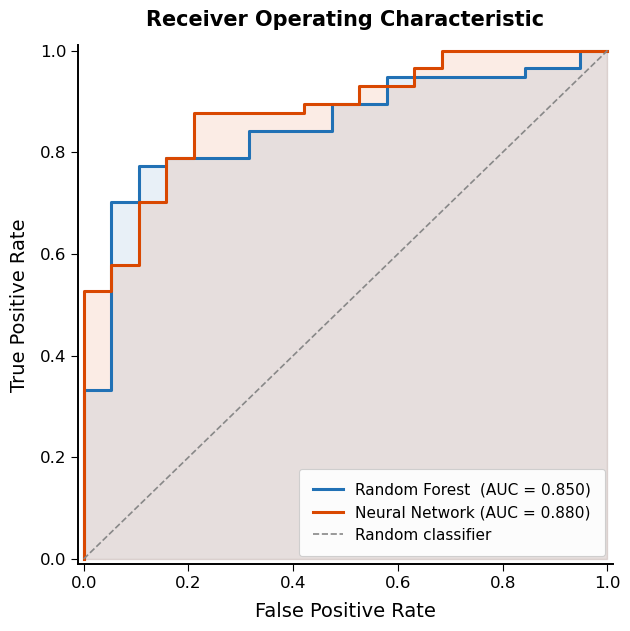

  ✓ ROC curve saved → F:\Experiments\PTT\Spheroids\all data\mcf7\roc_curve_rf_nn.png


In [255]:
print("\n[11] Paper-quality ROC curve...")

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 13, 'axes.linewidth': 1.4,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'xtick.major.size': 5, 'ytick.major.size': 5,
})

fpr_rf, tpr_rf, _ = roc_curve(y_test_final, y_proba_final)
fpr_nn, tpr_nn, _ = roc_curve(y_test_final, nn_proba_alive)
auc_rf_val = roc_auc_score(y_test_final, y_proba_final)
auc_nn_val = roc_auc_score(y_test_final, nn_proba_alive)

fig_roc, ax_roc = plt.subplots(figsize=(6.5, 6.5))

ax_roc.fill_between(fpr_rf, tpr_rf, alpha=0.10, color='#2171b5')
ax_roc.fill_between(fpr_nn, tpr_nn, alpha=0.10, color='#d94801')

ax_roc.plot(fpr_rf, tpr_rf, lw=2.2, color='#2171b5',  label=f'Random Forest  (AUC = {auc_rf_val:.3f})')
ax_roc.plot(fpr_nn, tpr_nn, lw=2.2, color='#d94801',  label=f'Neural Network (AUC = {auc_nn_val:.3f})')
ax_roc.plot([0,1],[0,1], lw=1.2, color='#888888', linestyle='--', label='Random classifier')

ax_roc.set_xlim([-0.01, 1.01]); ax_roc.set_ylim([-0.01, 1.01])
ax_roc.set_xlabel('False Positive Rate', fontsize=14, labelpad=8)
ax_roc.set_ylabel('True Positive Rate',  fontsize=14, labelpad=8)
ax_roc.set_title('Receiver Operating Characteristic', fontsize=15, fontweight='bold', pad=14)
ax_roc.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax_roc.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax_roc.tick_params(labelsize=12)
legend_roc = ax_roc.legend(fontsize=11, frameon=True, loc='lower right',
                            framealpha=0.92, edgecolor='#cccccc',
                            borderpad=0.9, handlelength=2.0)
legend_roc.get_frame().set_linewidth(0.8)

plt.tight_layout()
roc_path = OUTPUT_DIR / 'roc_curve_rf_nn.png'
plt.savefig(roc_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
print(f"  ✓ ROC curve saved → {roc_path}")


## 12. Paper-Quality K-Fold Metrics Box Plots


[12] Paper-quality K-fold box plots (RF only, NN only, RF vs NN)...


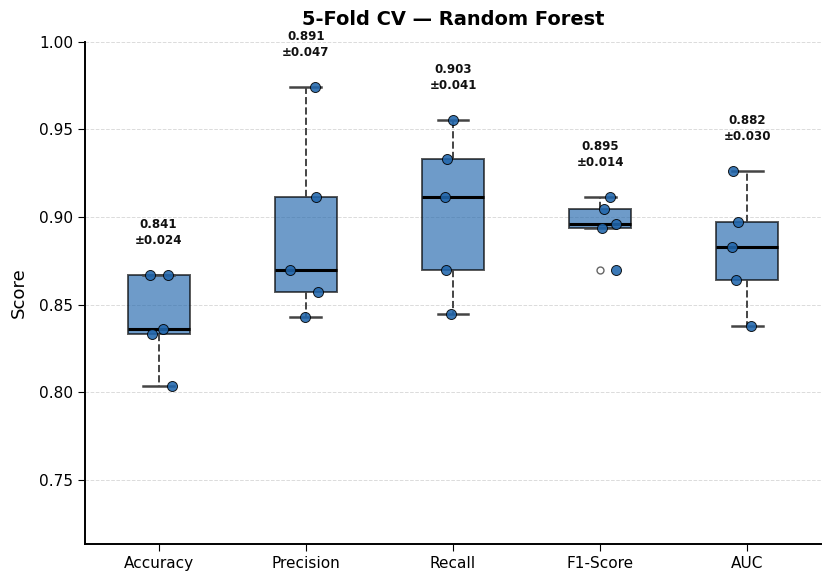

  ✓ RF box plot saved → F:\Experiments\PTT\Spheroids\all data\mcf7\kfold_metrics_boxplot_RF.png


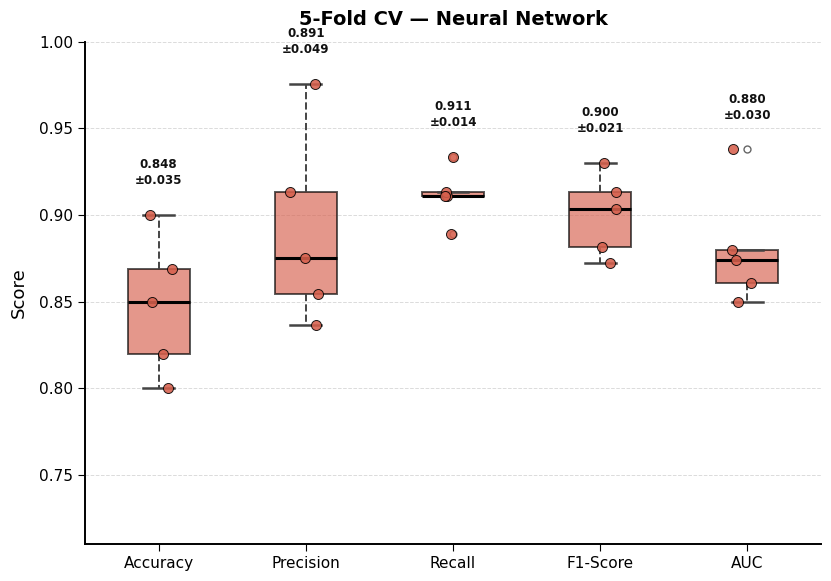

  ✓ NN box plot saved → F:\Experiments\PTT\Spheroids\all data\mcf7\kfold_metrics_boxplot_NN.png


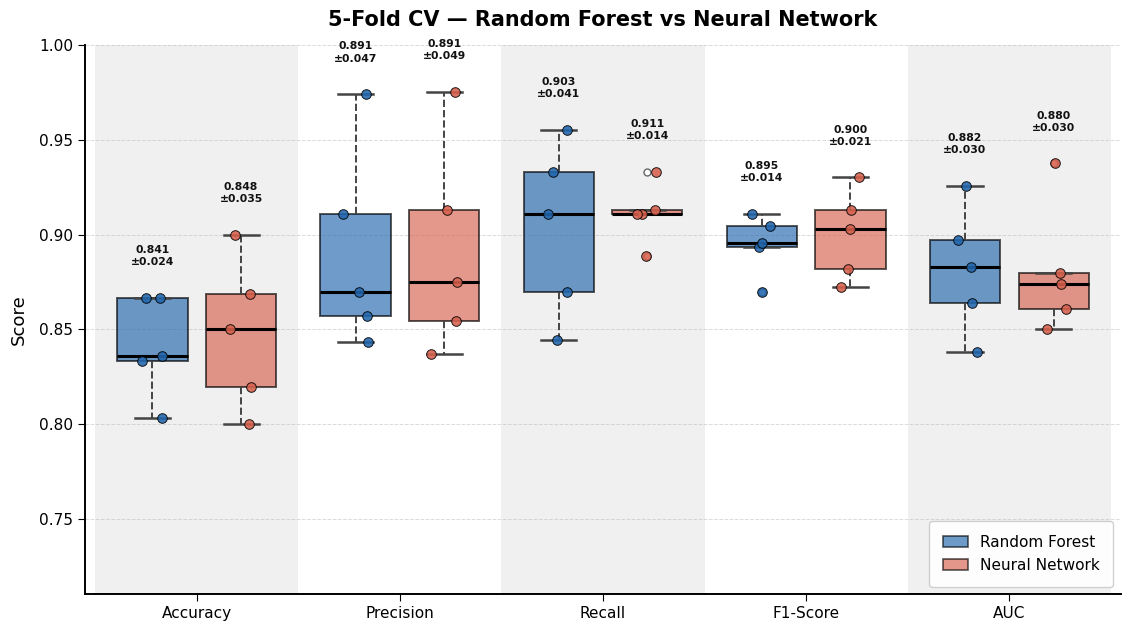

  ✓ RF vs NN box plot saved → F:\Experiments\PTT\Spheroids\all data\mcf7\kfold_metrics_boxplot_RF_vs_NN.png


In [256]:
print("\n[12] Paper-quality K-fold box plots (RF only, NN only, RF vs NN)...")

METRIC_LABELS  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
RF_METRIC_DATA = [fold_accuracies,    fold_precisions,    fold_recalls,
                  fold_f1_scores,     fold_auc_scores]
NN_METRIC_DATA = [nn_fold_accuracies, nn_fold_precisions, nn_fold_recalls,
                  nn_fold_f1_scores,  nn_fold_auc_scores]
RF_COLOR = '#2166ac'; NN_COLOR = '#d6604d'


def _paper_boxplot(ax, metric_data, metric_labels, color, model_name):
    bp = ax.boxplot(
        metric_data, positions=range(len(metric_labels)), widths=0.42,
        patch_artist=True, notch=False,
        medianprops=dict(color='black',   linewidth=2.2),
        whiskerprops=dict(color='#444444', linewidth=1.4, linestyle='--'),
        capprops=dict(color='#444444',    linewidth=1.8),
        flierprops=dict(marker='o', markersize=5, linestyle='none',
                        markeredgecolor='#666666', markerfacecolor='white', markeredgewidth=1.0),
        boxprops=dict(linewidth=1.4),
    )
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.65)

    rng = np.random.default_rng(7)
    for i, vals in enumerate(metric_data):
        jit = rng.uniform(-0.11, 0.11, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jit, vals, color=color, s=52, zorder=5,
                   edgecolors='black', linewidths=0.7, alpha=0.88)

    for i, vals in enumerate(metric_data):
        m, s = np.mean(vals), np.std(vals)
        ax.text(i, max(vals) + 0.016, f'{m:.3f}\n±{s:.3f}', ha='center', va='bottom',
                fontsize=8.5, color='#111111', fontweight='bold', linespacing=1.3)

    ax.set_xticks(range(len(metric_labels))); ax.set_xticklabels(metric_labels, fontsize=12)
    ax.set_ylabel('Score', fontsize=13, labelpad=8)
    ax.set_title(f'{n_splits}-Fold CV — {model_name}', fontsize=14, fontweight='bold', pad=12)

    all_flat = [v for vals in metric_data for v in vals]
    ax.set_ylim(max(0, min(all_flat) - 0.09), min(1.0, max(all_flat) + 0.13))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.tick_params(axis='both', labelsize=11, direction='out', length=5)
    for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
    for sp in ['left', 'bottom']: ax.spines[sp].set_linewidth(1.4)
    ax.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.45, zorder=0)


# RF only
fig_rf_bp, ax_rf_bp = plt.subplots(figsize=(8.5, 6.0))
_paper_boxplot(ax_rf_bp, RF_METRIC_DATA, METRIC_LABELS, RF_COLOR, 'Random Forest')
plt.tight_layout()
rf_bp_path = OUTPUT_DIR / 'kfold_metrics_boxplot_RF.png'
plt.savefig(rf_bp_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
print(f"  ✓ RF box plot saved → {rf_bp_path}")

# NN only
fig_nn_bp, ax_nn_bp = plt.subplots(figsize=(8.5, 6.0))
_paper_boxplot(ax_nn_bp, NN_METRIC_DATA, METRIC_LABELS, NN_COLOR, 'Neural Network')
plt.tight_layout()
nn_bp_path = OUTPUT_DIR / 'kfold_metrics_boxplot_NN.png'
plt.savefig(nn_bp_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
print(f"  ✓ NN box plot saved → {nn_bp_path}")

# RF vs NN side by side
from matplotlib.patches import Patch

n_metrics  = len(METRIC_LABELS)
GROUP_GAP  = 1.1
BOX_OFFSET = 0.24
rf_positions = [i * GROUP_GAP - BOX_OFFSET for i in range(n_metrics)]
nn_positions = [i * GROUP_GAP + BOX_OFFSET for i in range(n_metrics)]

fig_cmp, ax_cmp = plt.subplots(figsize=(11.5, 6.5))

def _side_boxplot(ax, positions, metric_data, color, label):
    bp = ax.boxplot(
        metric_data, positions=positions, widths=0.38, patch_artist=True, notch=False,
        medianprops=dict(color='black',   linewidth=2.2),
        whiskerprops=dict(color='#444444', linewidth=1.4, linestyle='--'),
        capprops=dict(color='#444444',    linewidth=1.8),
        flierprops=dict(marker='o', markersize=5, linestyle='none',
                        markeredgecolor='#666666', markerfacecolor='white', markeredgewidth=1.0),
        boxprops=dict(linewidth=1.4),
    )
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(0.65)

    rng = np.random.default_rng(13)
    for pos, vals in zip(positions, metric_data):
        jit = rng.uniform(-0.07, 0.07, size=len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals, color=color, s=48, zorder=5,
                   edgecolors='black', linewidths=0.7, alpha=0.88)

    for pos, vals in zip(positions, metric_data):
        m, s = np.mean(vals), np.std(vals)
        ax.text(pos, max(vals) + 0.016, f'{m:.3f}\n±{s:.3f}', ha='center', va='bottom',
                fontsize=7.8, color='#111111', fontweight='bold', linespacing=1.3)

    return Patch(facecolor=color, alpha=0.65, edgecolor='black', linewidth=1.2, label=label)

proxy_rf = _side_boxplot(ax_cmp, rf_positions, RF_METRIC_DATA, RF_COLOR, 'Random Forest')
proxy_nn = _side_boxplot(ax_cmp, nn_positions, NN_METRIC_DATA, NN_COLOR, 'Neural Network')

for i in range(n_metrics):
    if i % 2 == 0:
        ax_cmp.axvspan(i*GROUP_GAP - GROUP_GAP/2, i*GROUP_GAP + GROUP_GAP/2,
                       color='#f0f0f0', zorder=0, linewidth=0)

group_centers = [i * GROUP_GAP for i in range(n_metrics)]
ax_cmp.set_xticks(group_centers); ax_cmp.set_xticklabels(METRIC_LABELS, fontsize=12.5)
ax_cmp.set_xlim(-GROUP_GAP*0.55, (n_metrics-1)*GROUP_GAP + GROUP_GAP*0.55)
ax_cmp.set_ylabel('Score', fontsize=13, labelpad=8)
ax_cmp.set_title(f'{n_splits}-Fold CV — Random Forest vs Neural Network',
                 fontsize=15, fontweight='bold', pad=14)
all_flat_cmp = [v for md in [RF_METRIC_DATA, NN_METRIC_DATA] for vals in md for v in vals]
ax_cmp.set_ylim(max(0, min(all_flat_cmp) - 0.09), min(1.0, max(all_flat_cmp) + 0.14))
ax_cmp.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax_cmp.tick_params(axis='both', labelsize=11, direction='out', length=5)
for sp in ['top', 'right']: ax_cmp.spines[sp].set_visible(False)
for sp in ['left', 'bottom']: ax_cmp.spines[sp].set_linewidth(1.4)
ax_cmp.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.45, zorder=0)
ax_cmp.legend(handles=[proxy_rf, proxy_nn], fontsize=11, frameon=True, loc='lower right',
              framealpha=0.92, edgecolor='#cccccc', borderpad=0.9, handlelength=1.6)

plt.tight_layout()
cmp_bp_path = OUTPUT_DIR / 'kfold_metrics_boxplot_RF_vs_NN.png'
plt.savefig(cmp_bp_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show(); plt.close()
print(f"  ✓ RF vs NN box plot saved → {cmp_bp_path}")

plt.rcParams.update(plt.rcParamsDefault)


## Final Summary

In [257]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

ic50_summary = ""
if max_temp_col:
    ic50_summary = f"""
IC50 (Temperature at P(Alive)=0.5):
  RF Best Fold : {f'{ic50_bf:.2f} °C' if ic50_bf is not None else 'outside data range'}
  RF Test Set  : {f'{ic50_rf:.2f} °C' if ic50_rf is not None else 'outside data range'}
  NN Test Set  : {f'{ic50_nn:.2f} °C' if ic50_nn is not None else 'outside data range'}
"""

print(f"""
✓ K-Fold CV performed ({n_splits} folds)
✓ All metrics: Accuracy, Precision, Recall, F1, AUC
✓ Confusion matrices generated
✓ ROC curve created
✓ Temperature vs Predicted Label plots (RF best fold, RF test, NN test)
✓ Violin plot (RF / NN / True label)
✓ Predictions exported to CSV
✓ Paper-quality figures saved
{ic50_summary}
Key Findings:
  CV Accuracy : {np.mean(fold_accuracies)*100:.1f}% (±{np.std(fold_accuracies)*100:.1f}%)
  Test Accuracy: {final_acc*100:.1f}%
  ROC AUC     : {final_auc:.3f}
""")



ANALYSIS COMPLETE!

✓ K-Fold CV performed (5 folds)
✓ All metrics: Accuracy, Precision, Recall, F1, AUC
✓ Confusion matrices generated
✓ ROC curve created
✓ Temperature vs Predicted Label plots (RF best fold, RF test, NN test)
✓ Violin plot (RF / NN / True label)
✓ Predictions exported to CSV
✓ Paper-quality figures saved

IC50 (Temperature at P(Alive)=0.5):
  RF Best Fold : 57.72 °C
  RF Test Set  : 52.68 °C
  NN Test Set  : 65.18 °C

Key Findings:
  CV Accuracy : 84.1% (±2.4%)
  Test Accuracy: 80.3%
  ROC AUC     : 0.850

